In [1]:
1

1

Optimization terminated successfully.
         Current function value: -189.133286
         Iterations: 15
         Function evaluations: 30
 message: Solution found.
 success: True
  status: 0
     fun: -7.666552992013417
       x: 1.868204484697312
     nit: 15
    nfev: 15
8 188.7927830812204


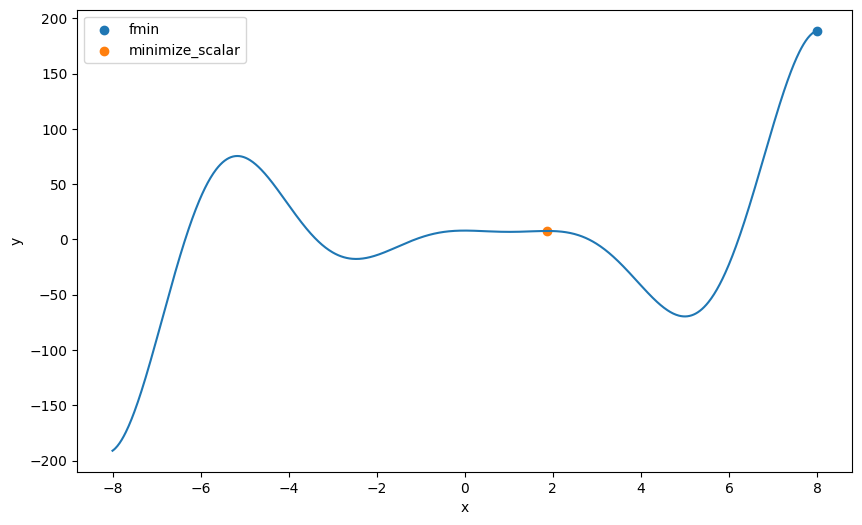

In [38]:
import numpy as np
from scipy.optimize import minimize_scalar, fmin
import matplotlib.pyplot as plt

def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def fm(x,w=8):
    return -f(x,w) # отриц функция


(x_min, x_max) = (-8, 8)

f_min=fmin(fm, 7)

if f_min>x_max:
    f_min=x_max
elif f_min<x_min:
    f_min=x_min

result = minimize_scalar(fm, bounds=[x_min, x_max], method='bounded') # не оптимальная точка
print(result)

x = f_min
y = f(x)
print(x,y)

plt.figure(figsize=(10,6))
x_arr=np.linspace(x_min,x_max,1000)
plt.plot(x_arr, f(x_arr))
plt.scatter(x,y, label = 'fmin')
plt.scatter(result.x, f(result.x), label = 'minimize_scalar')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

2 зд

In [30]:
import numpy as np
def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def bruteforce (w=8):

    (x_min, x_max) = (-8, 8)

    X_MIN_GLOBAL = x_min
    X_MAX_GLOBAL = x_max

    n_shag=0.1
    n_round=1
    xres=x_min
    tol = 1e-10

    while n_shag > tol:
        x_value = np.arange(x_min, x_max, n_shag)

        y_value = np.array([f(x,w) for x in x_value])
        max_value = -np.inf
        for y in y_value:
            if y > max_value:
                max_value = y
                xres = round(x_value[np.where(y_value==max_value)][0], n_round)

        x_min = max(X_MIN_GLOBAL, xres - n_shag)
        x_max = min(X_MAX_GLOBAL, xres + n_shag)
        n_round+=1
        n_shag/=10
        n_shag = round(n_shag, n_round)
        #print(xres, max_value, n_shag, x_max)
    return xres

bruteforce()

np.float64(7.999999999)

3

15.989786280661635
Optimization terminated successfully.
         Current function value: -187.665775
         Iterations: 15
         Function evaluations: 30
1.1956320740309185
Optimization terminated successfully.
         Current function value: -190.621448
         Iterations: 15
         Function evaluations: 30
7.7599249131922345
Optimization terminated successfully.
         Current function value: -189.182115
         Iterations: 15
         Function evaluations: 30
13.179558872945755
Optimization terminated successfully.
         Current function value: -188.146740
         Iterations: 15
         Function evaluations: 30
5.684672036472319
Optimization terminated successfully.
         Current function value: -189.615502
         Iterations: 15
         Function evaluations: 30
15.222038395404743
Optimization terminated successfully.
         Current function value: -187.793335
         Iterations: 15
         Function evaluations: 30
12.212596042182797
Optimization terminate

C:\Users\raven\AppData\Local\Temp\ipykernel_27156\4103897930.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


12.383250137678475
Optimization terminated successfully.
         Current function value: -188.290024
         Iterations: 15
         Function evaluations: 30
13.816670670346804
Optimization terminated successfully.
         Current function value: -188.034318
         Iterations: 15
         Function evaluations: 30
13.964674973725106
Optimization terminated successfully.
         Current function value: -188.008485
         Iterations: 15
         Function evaluations: 30
5.199256867107239
Optimization terminated successfully.
         Current function value: -189.719783
         Iterations: 15
         Function evaluations: 30
14.147711989642842
Optimization terminated successfully.
         Current function value: -187.976685
         Iterations: 15
         Function evaluations: 30
3.421187279491516
Optimization terminated successfully.
         Current function value: -190.111112
         Iterations: 15
         Function evaluations: 30
6.306764634406368
Optimization terminated 

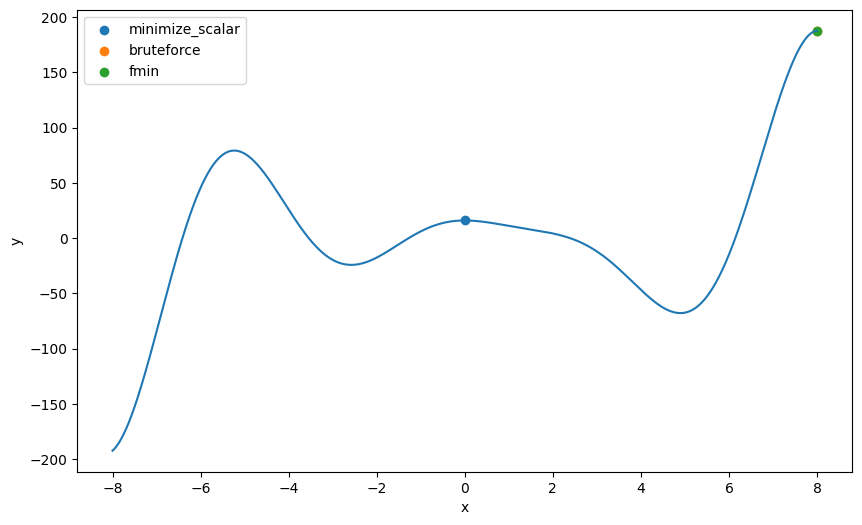

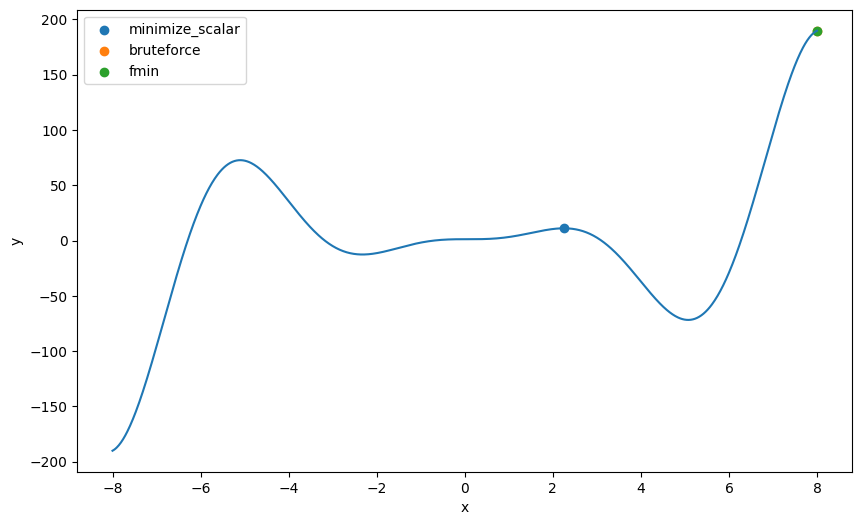

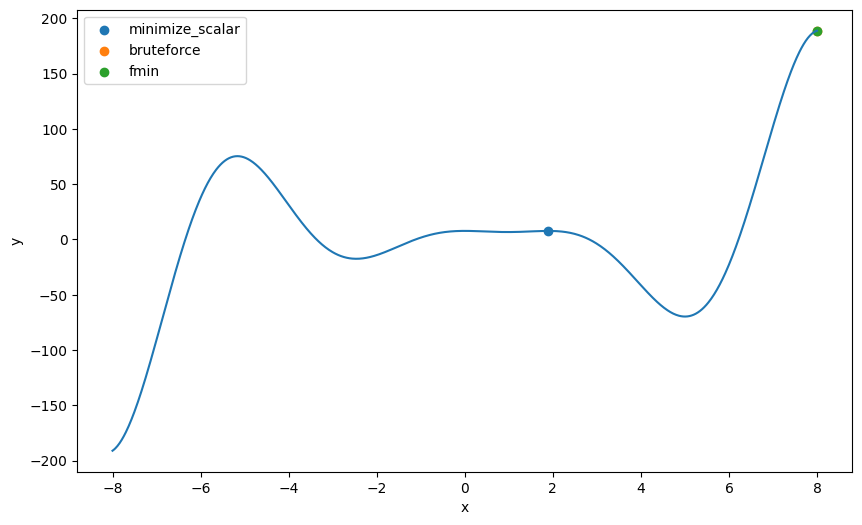

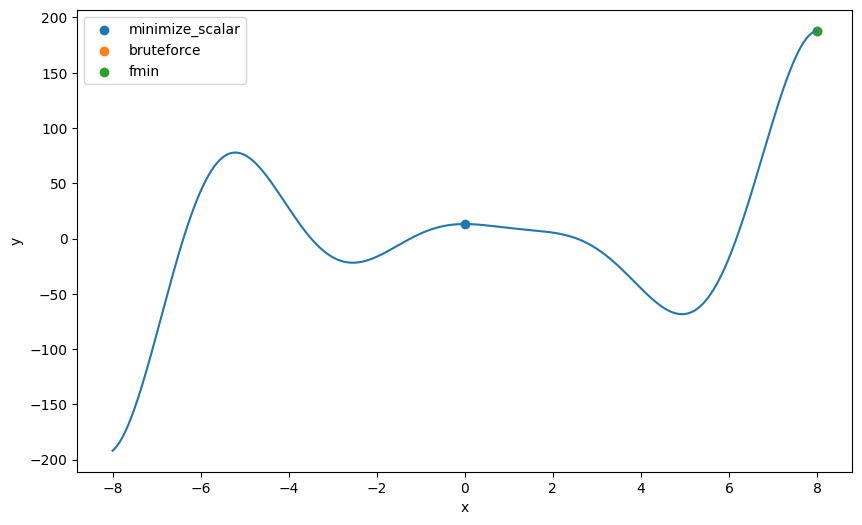

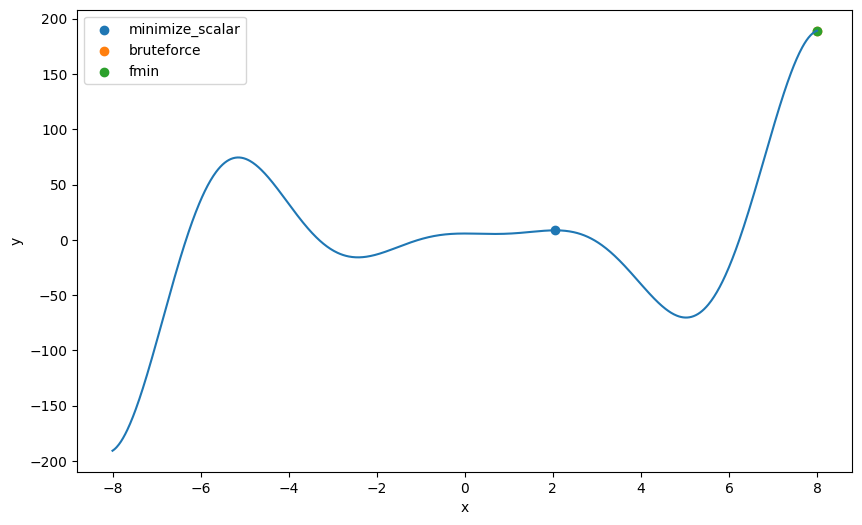

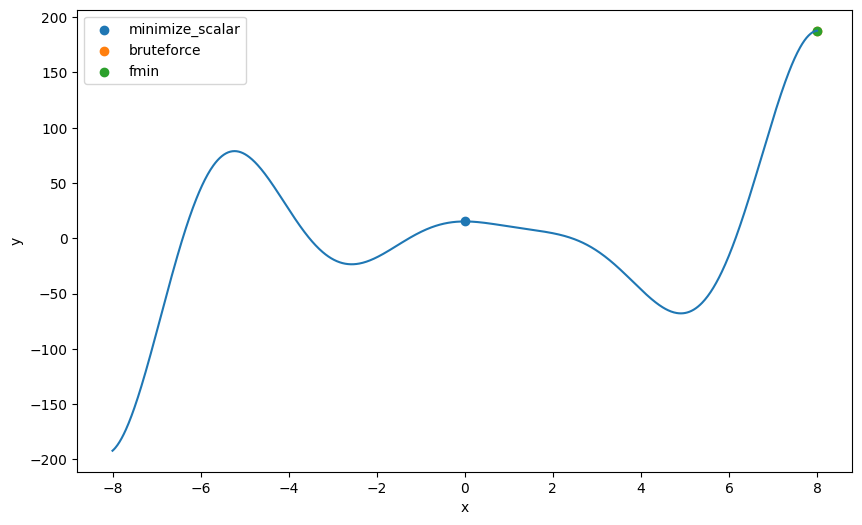

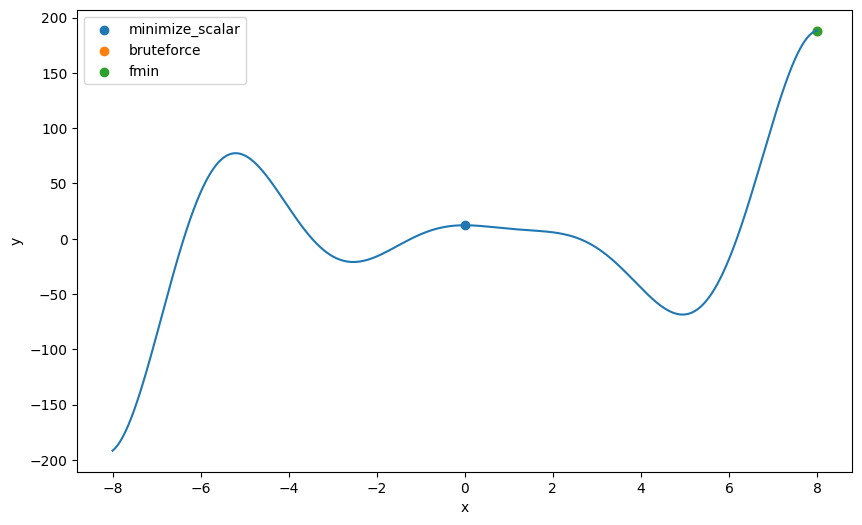

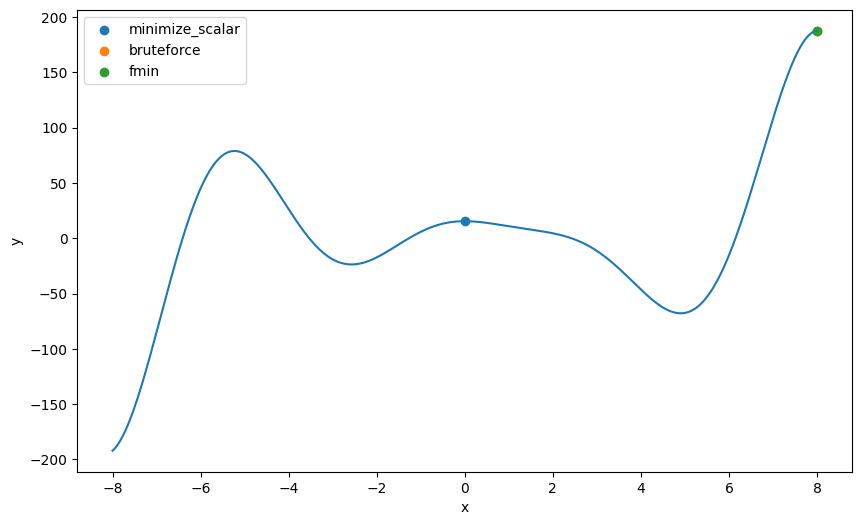

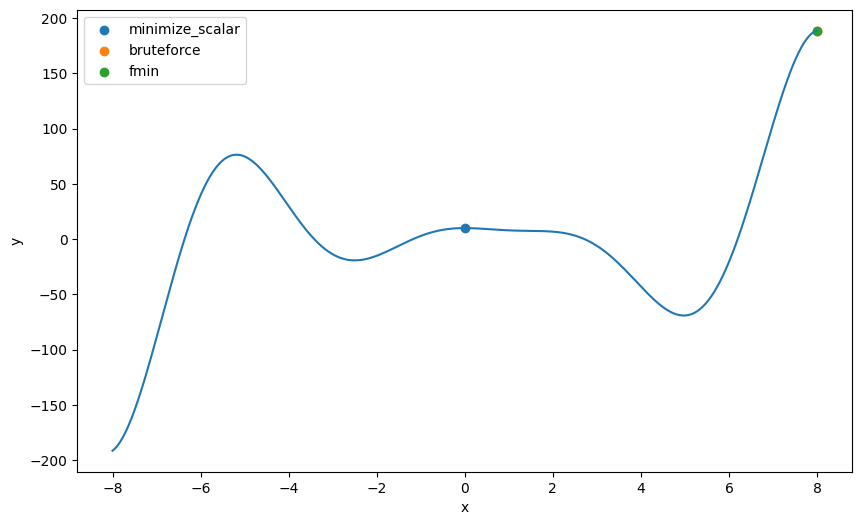

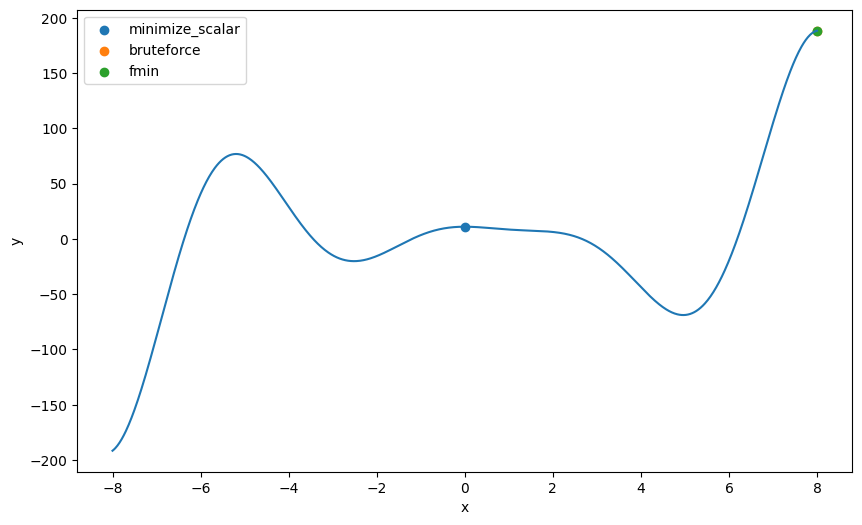

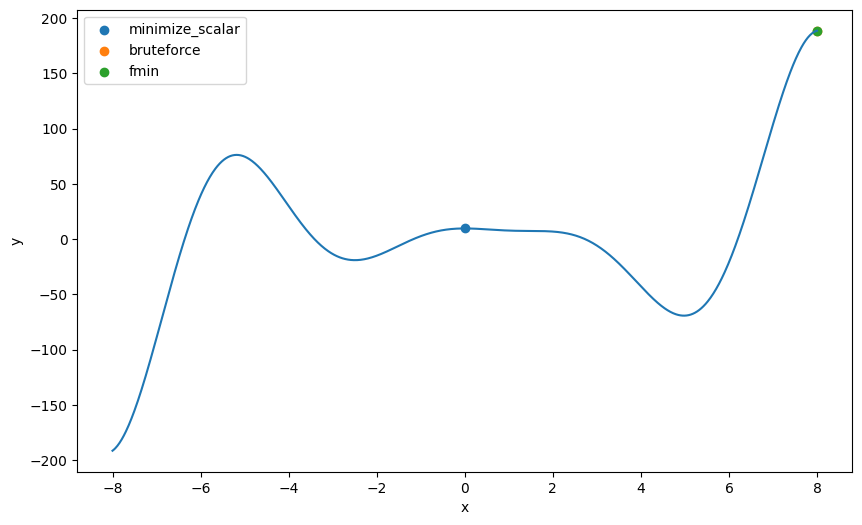

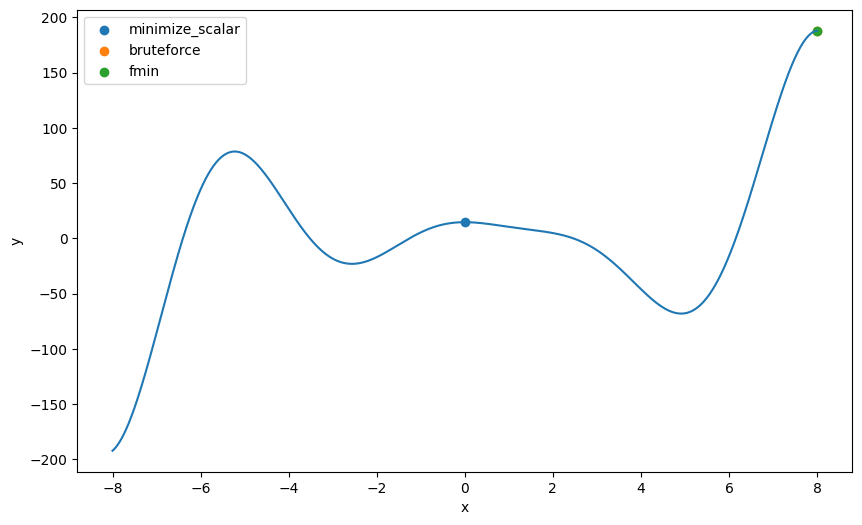

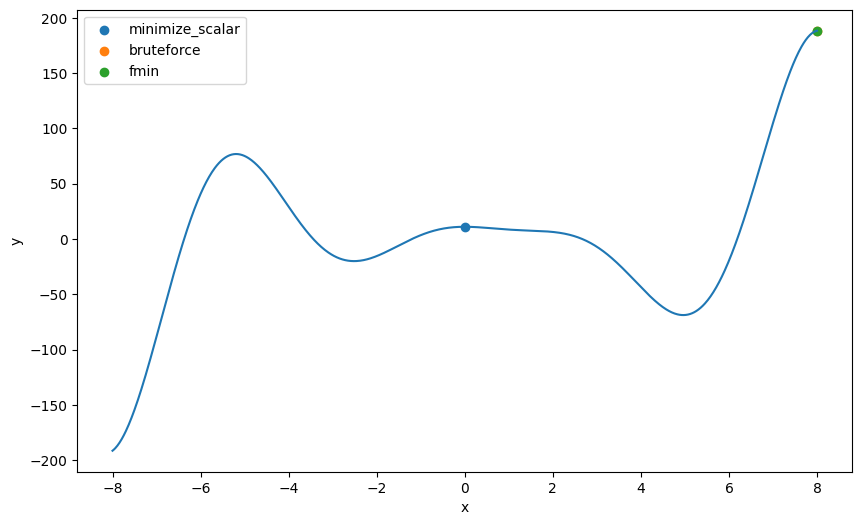

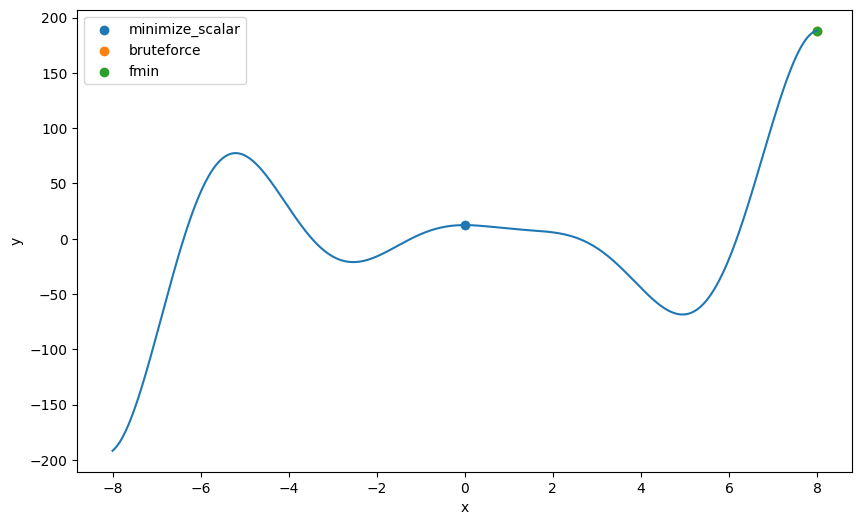

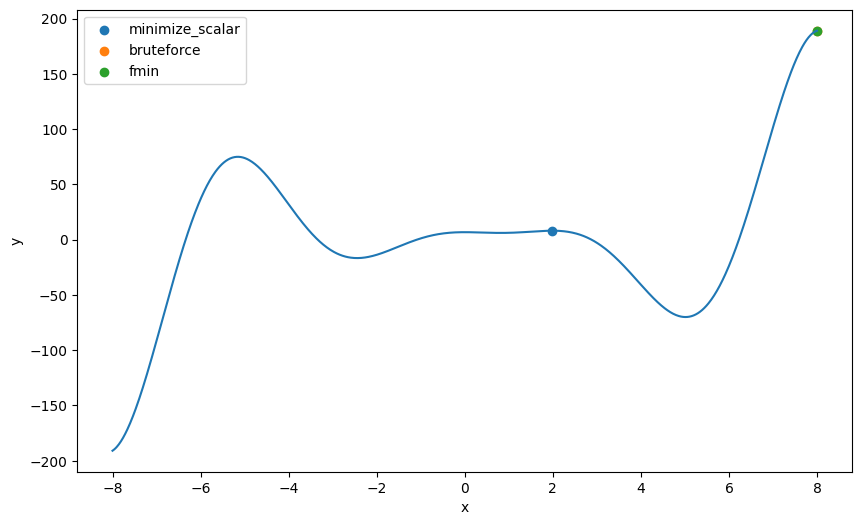

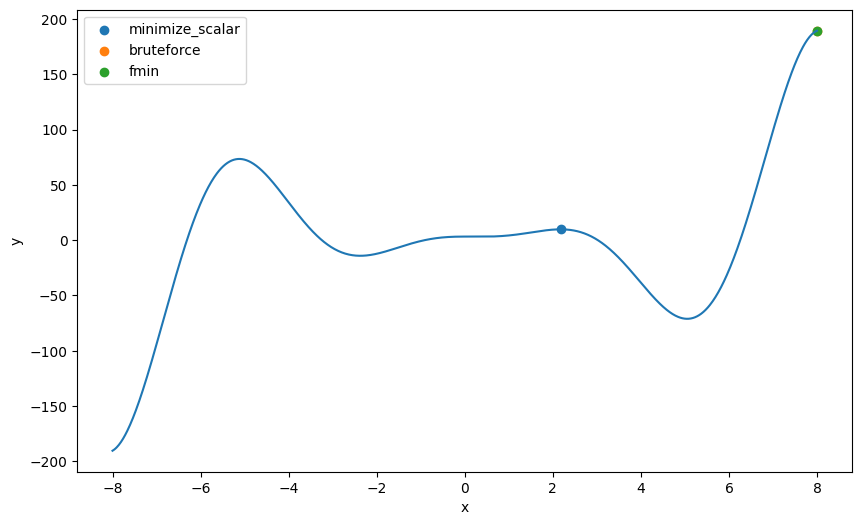

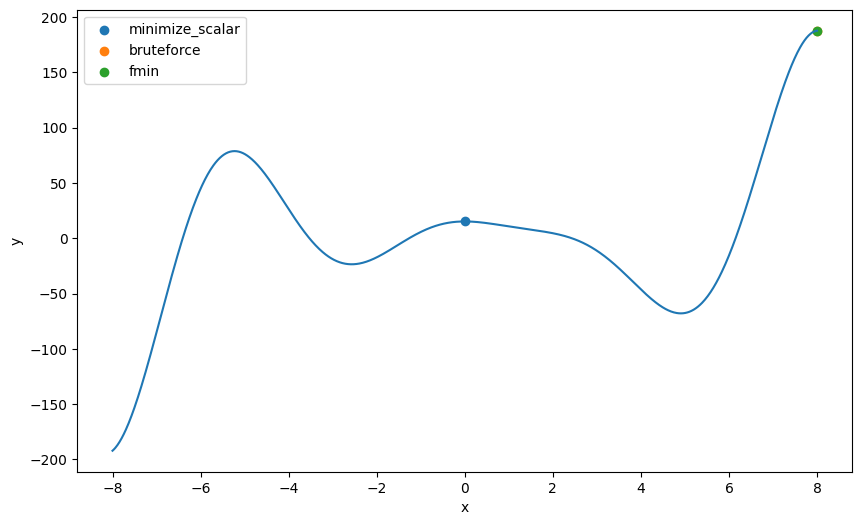

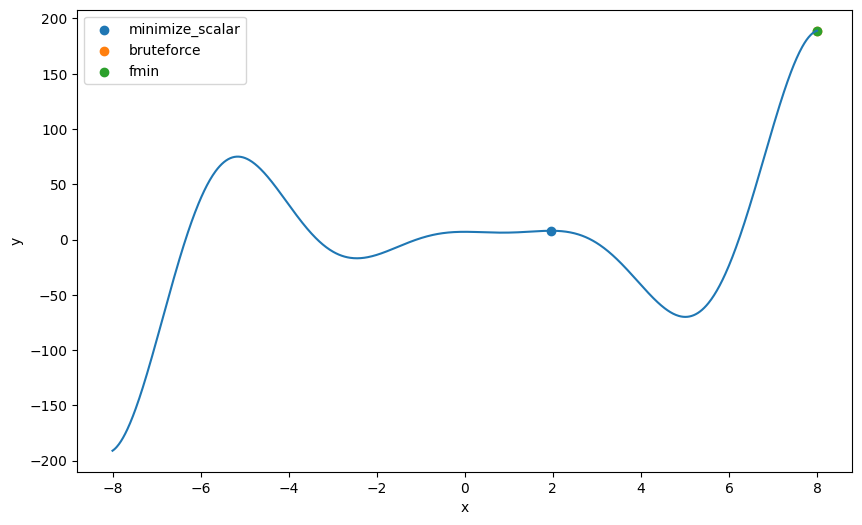

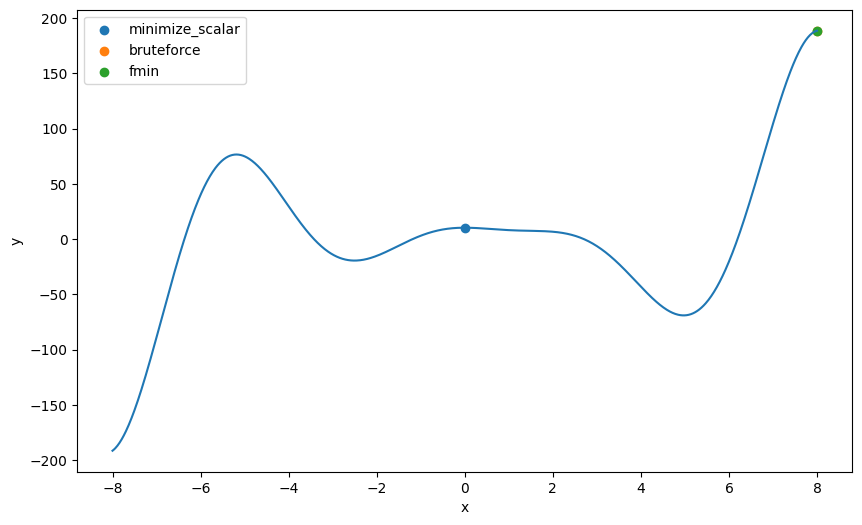

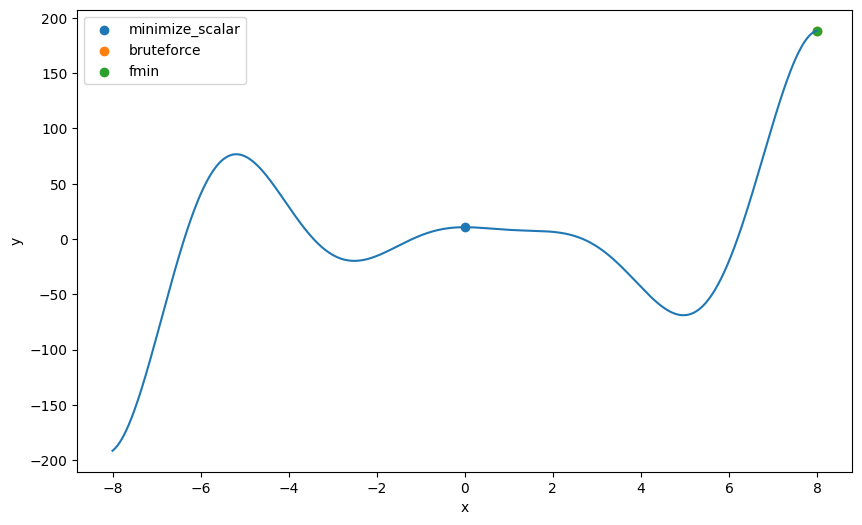

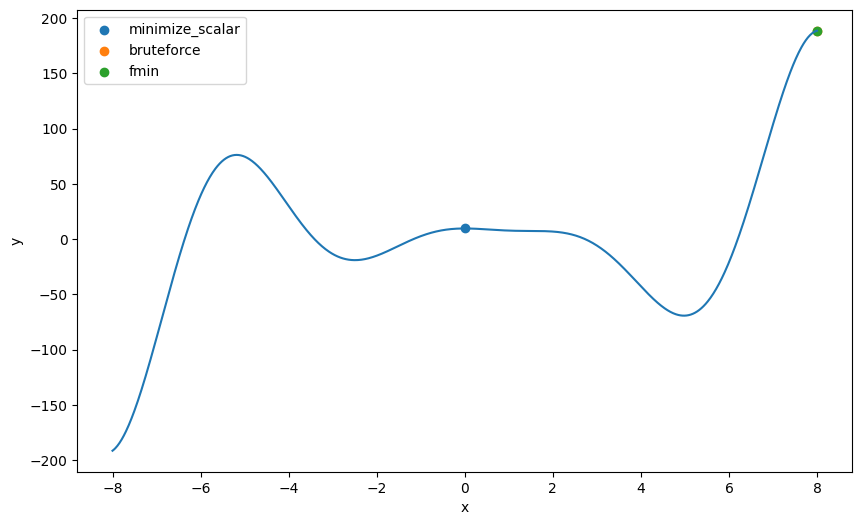

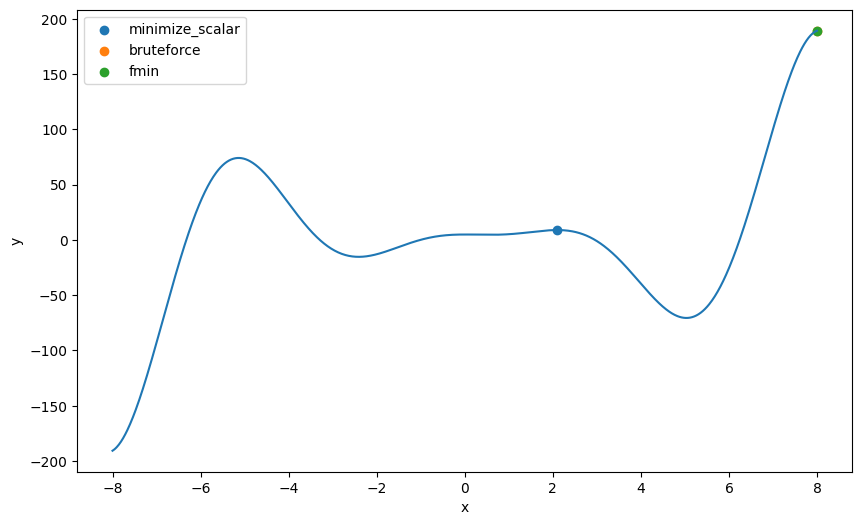

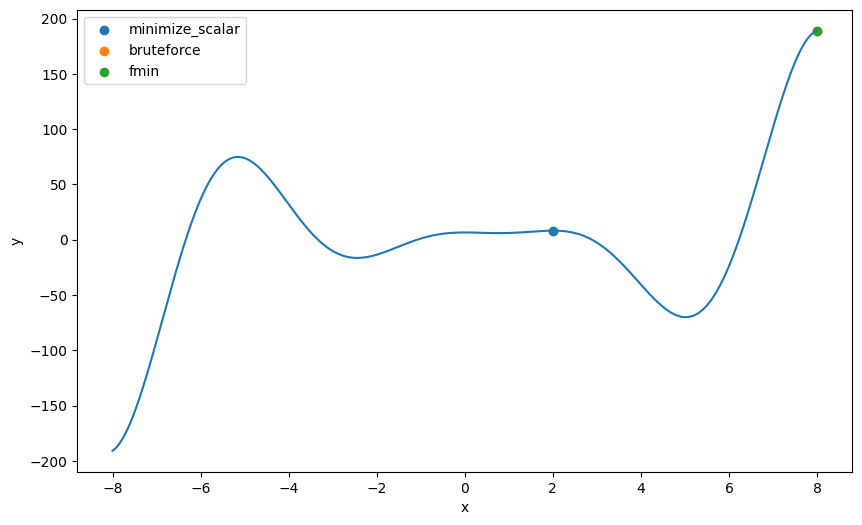

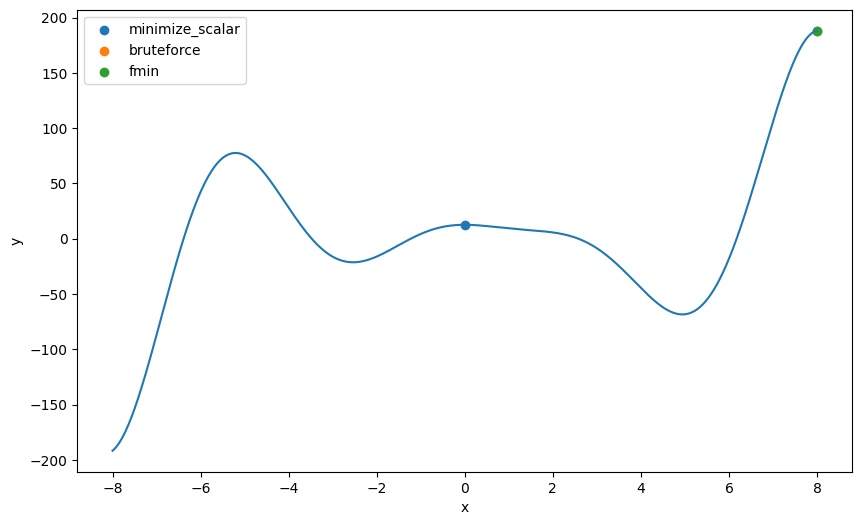

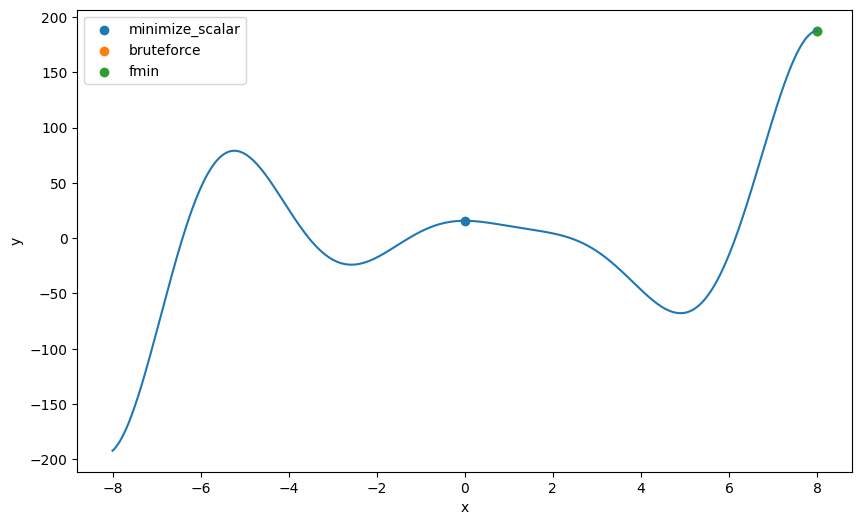

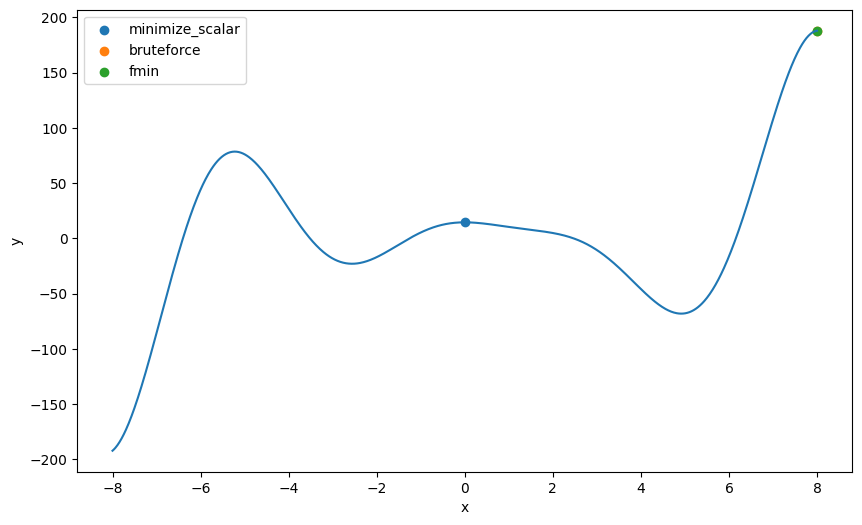

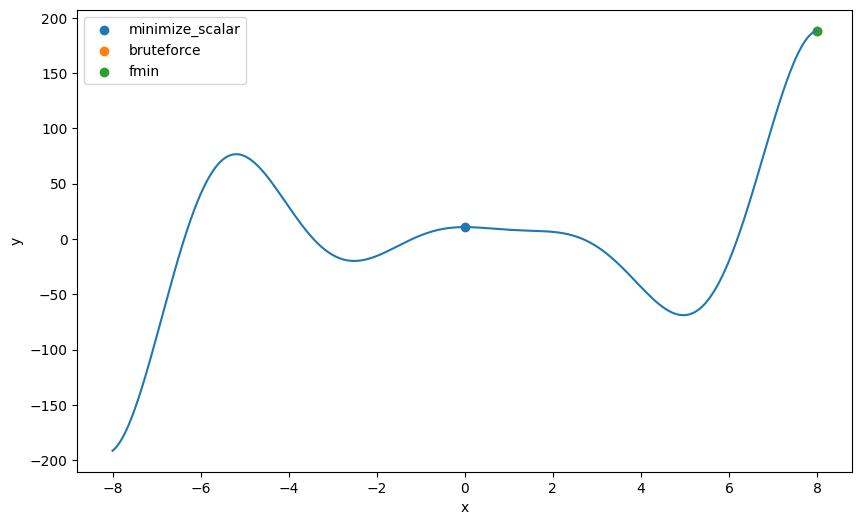

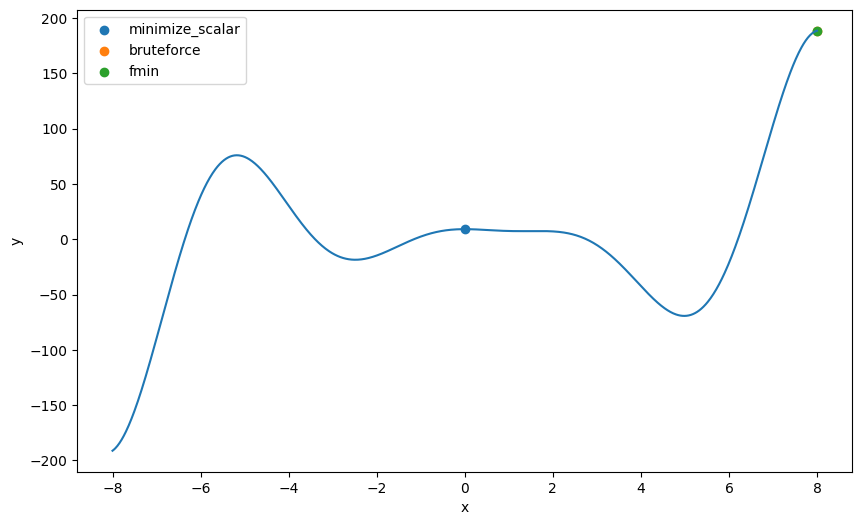

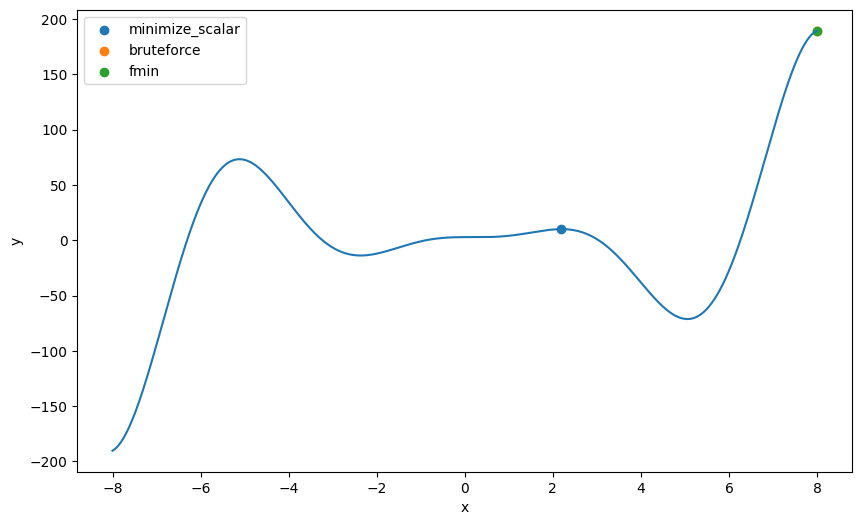

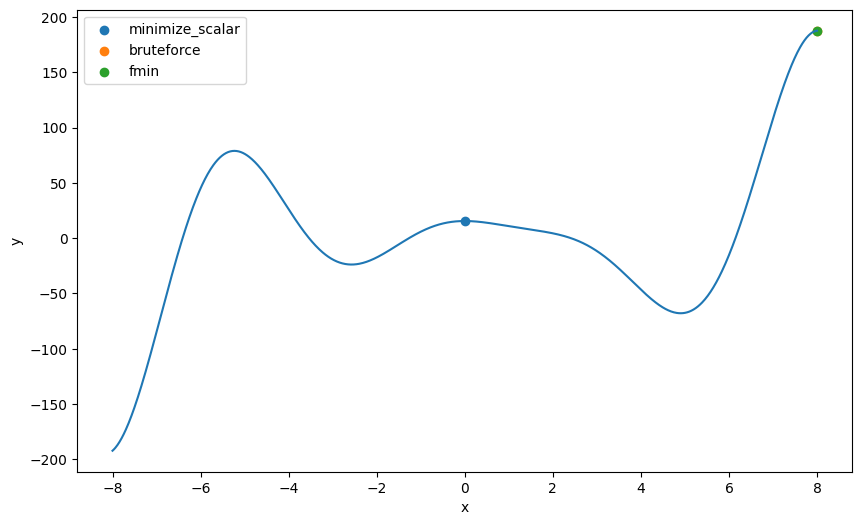

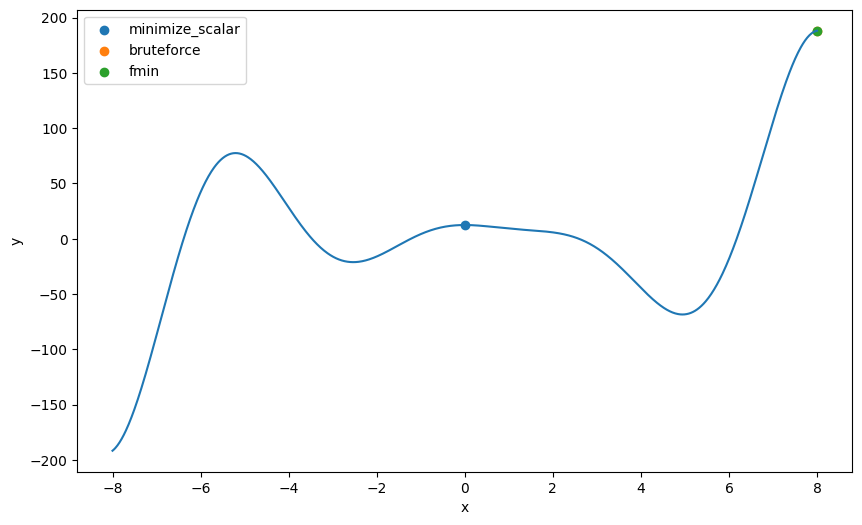

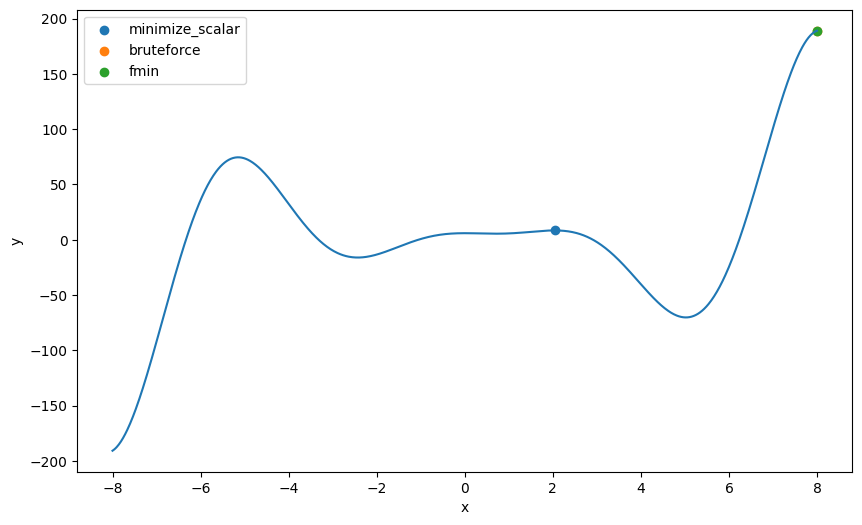

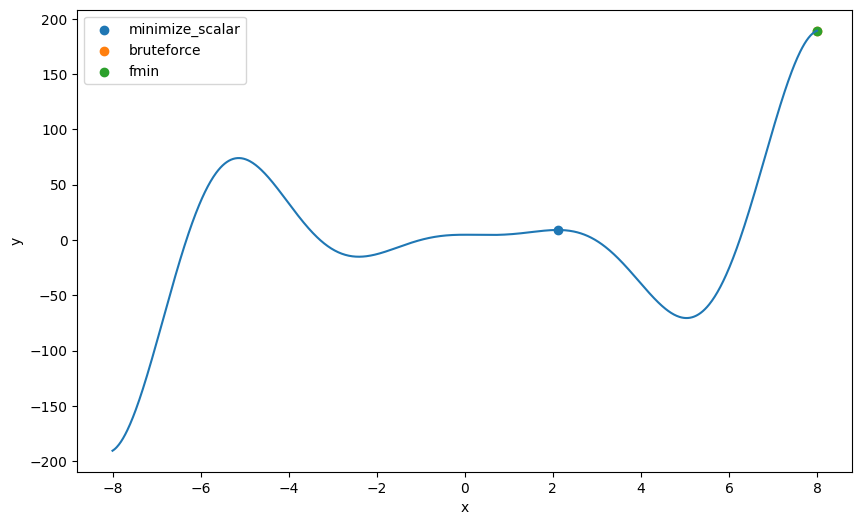

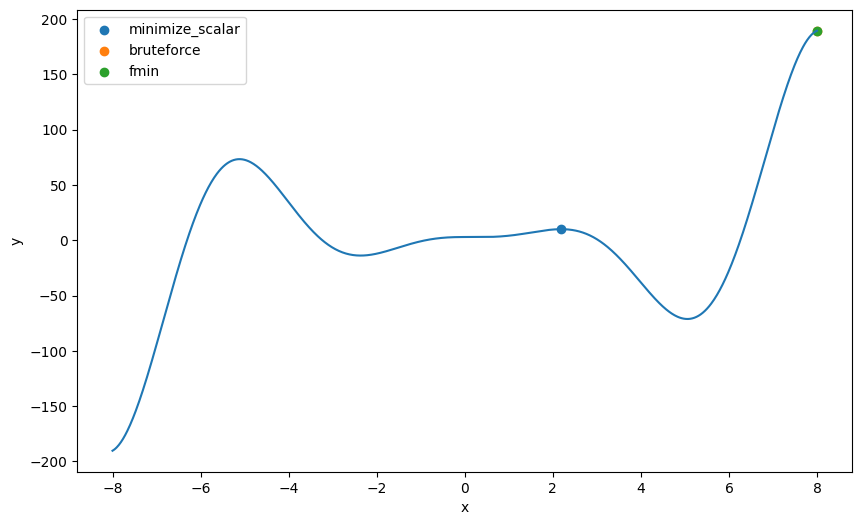

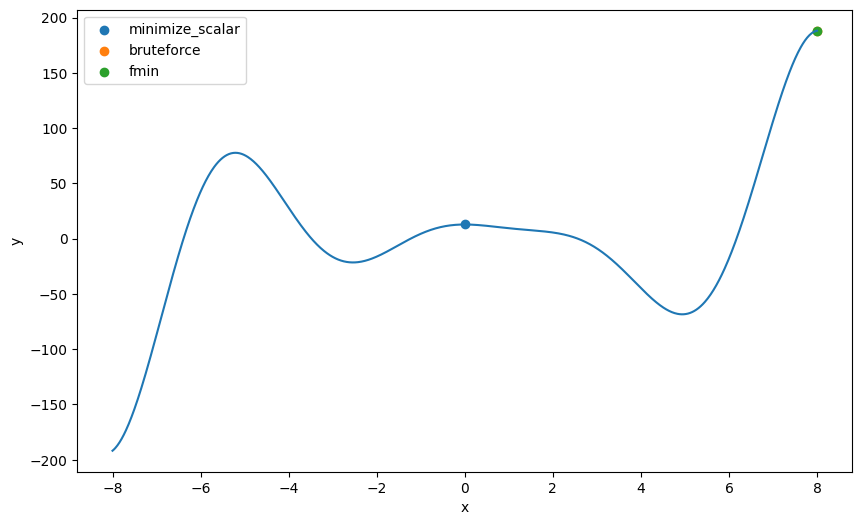

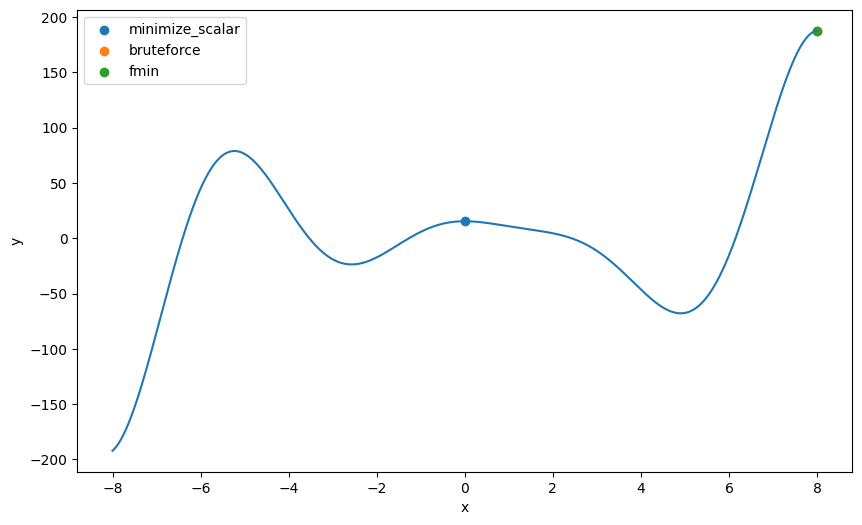

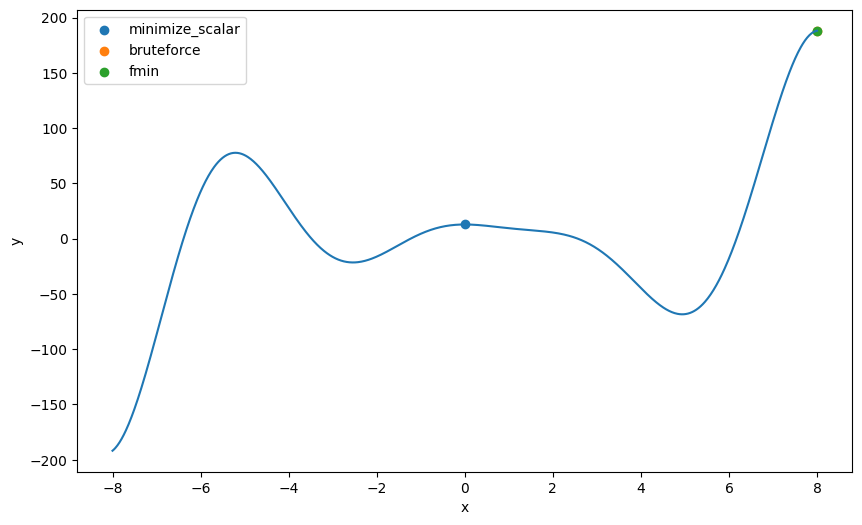

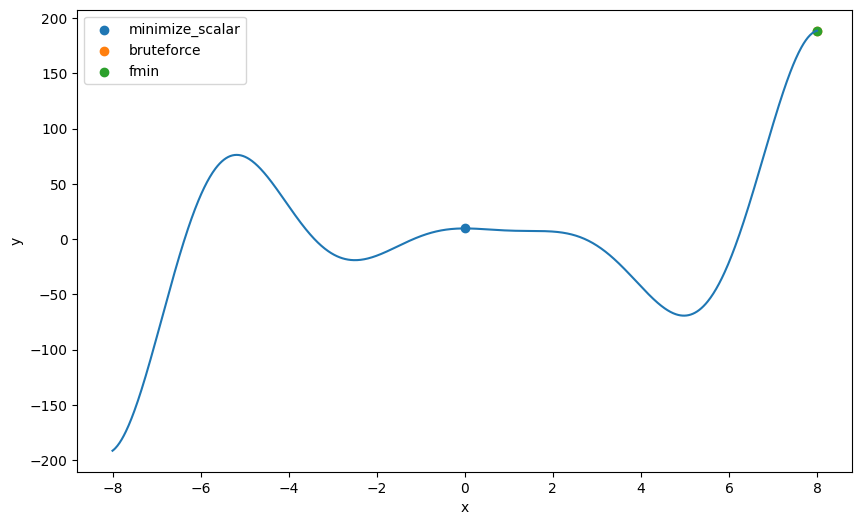

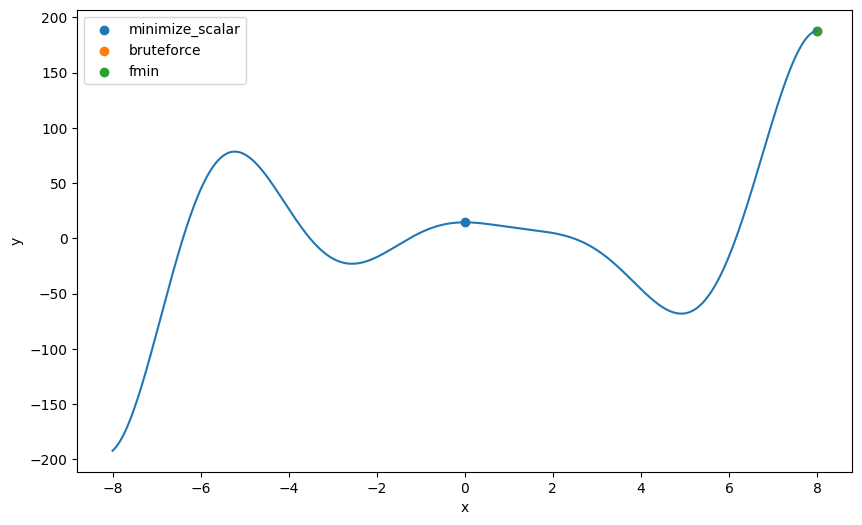

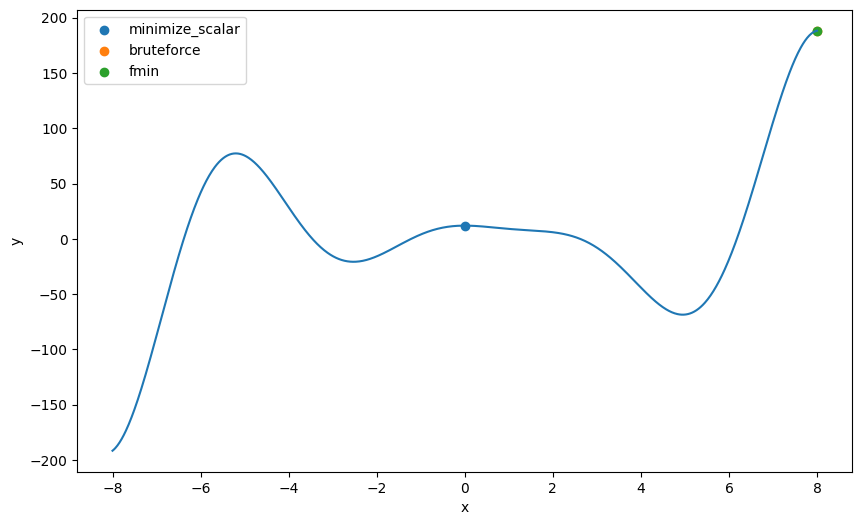

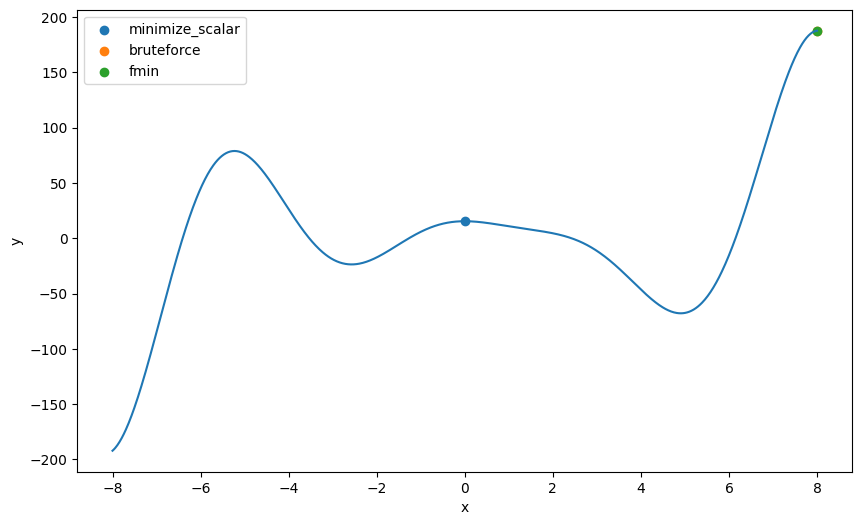

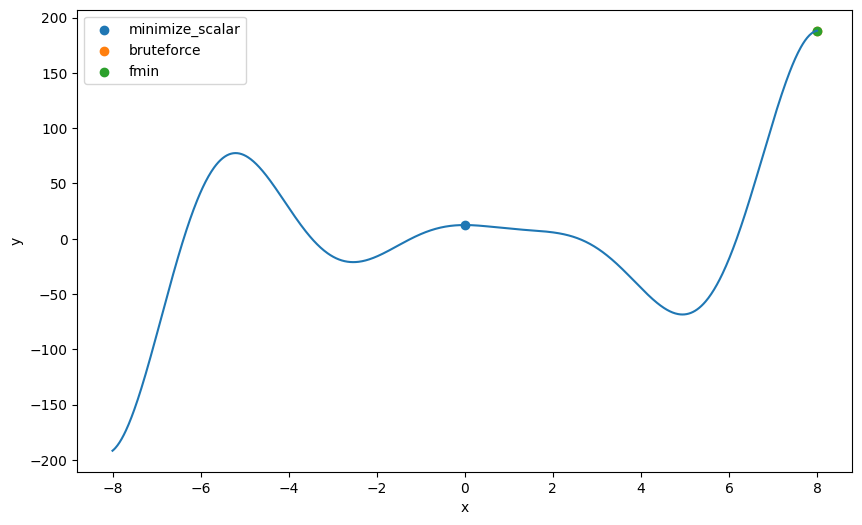

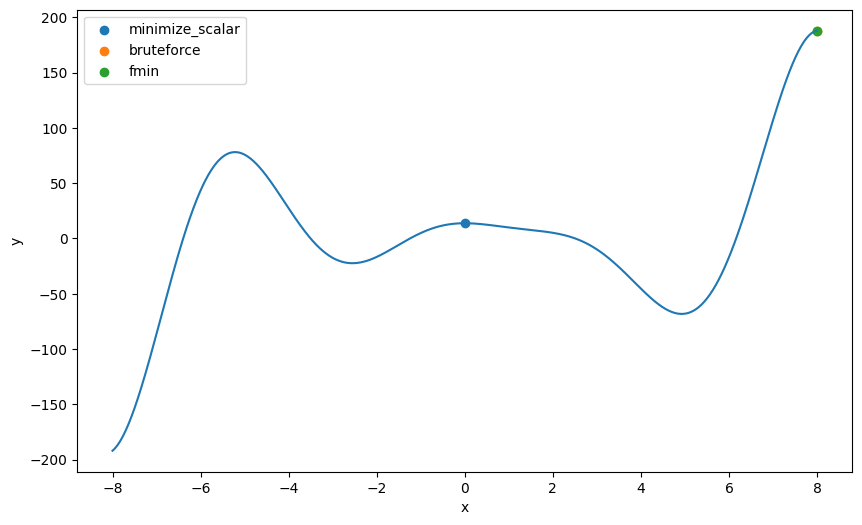

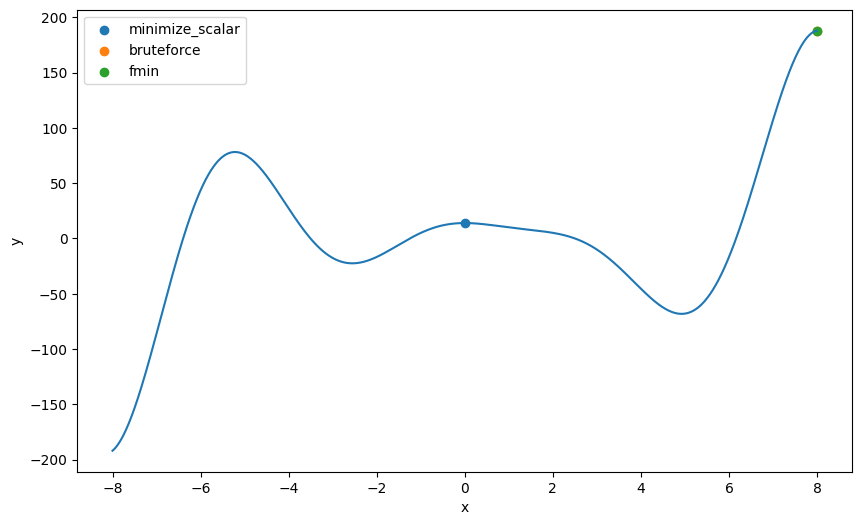

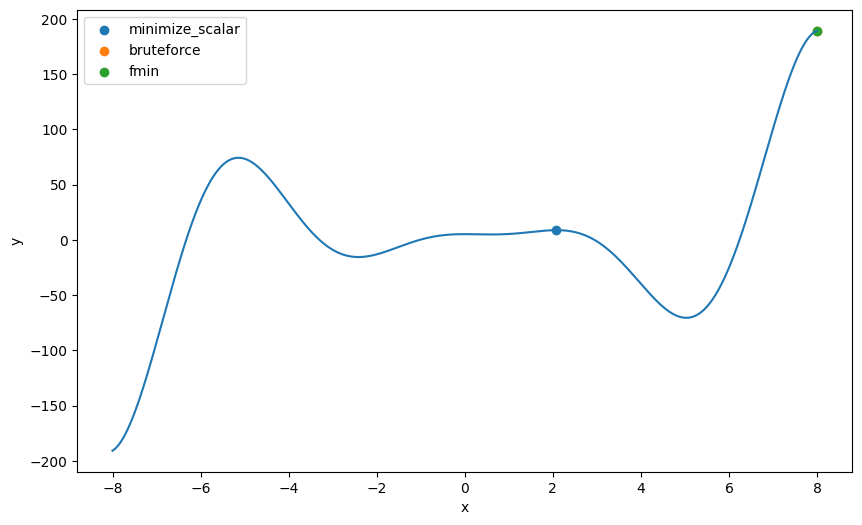

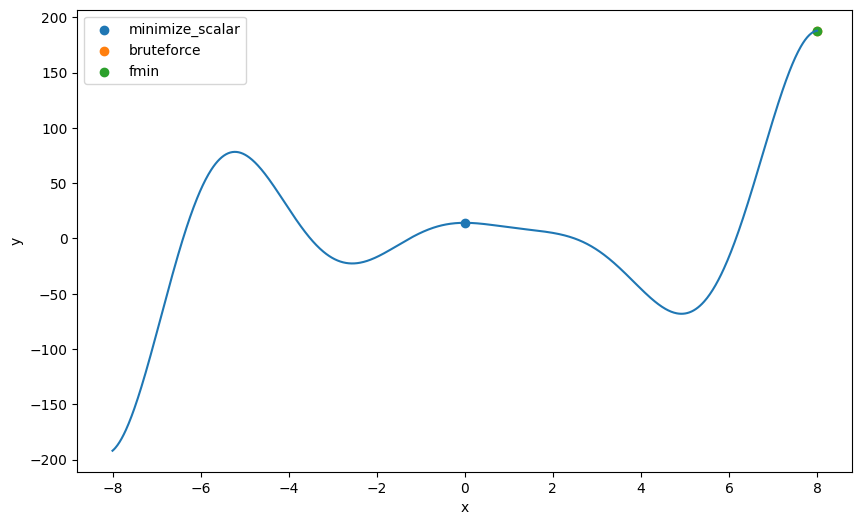

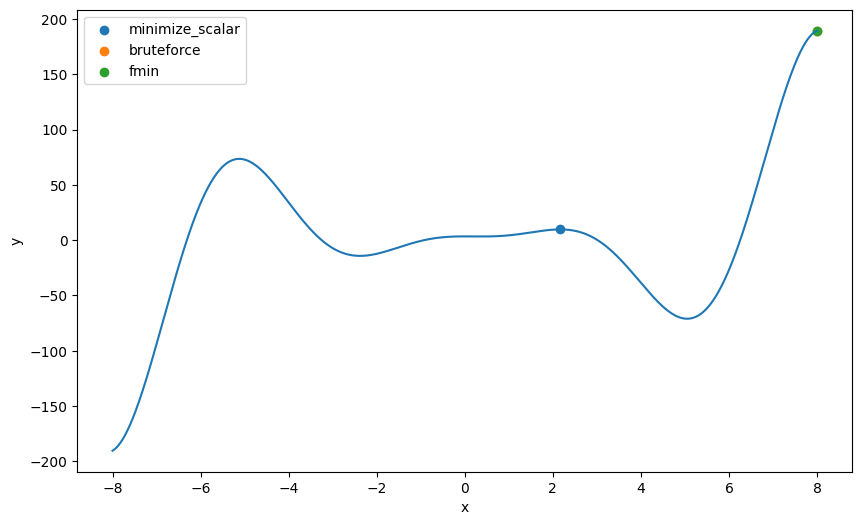

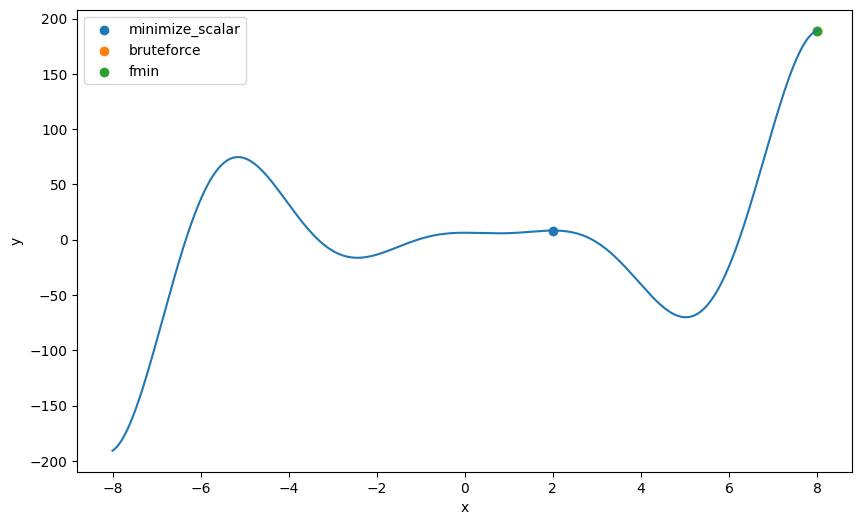

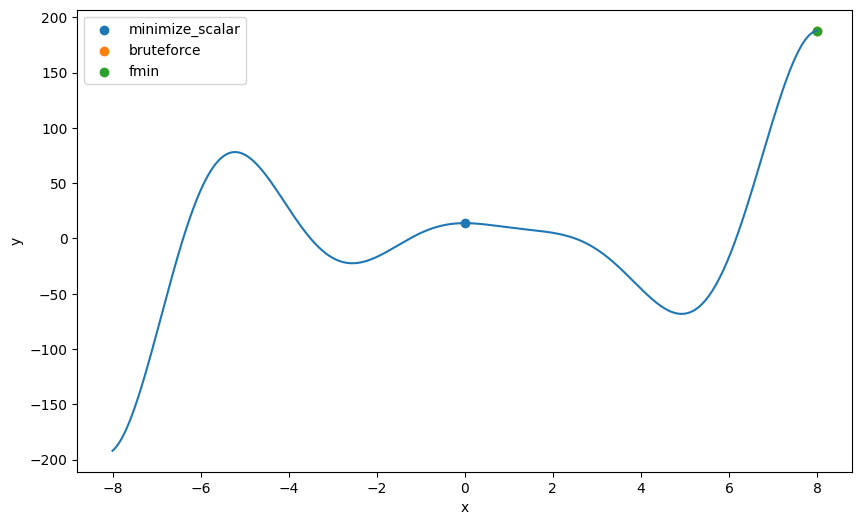

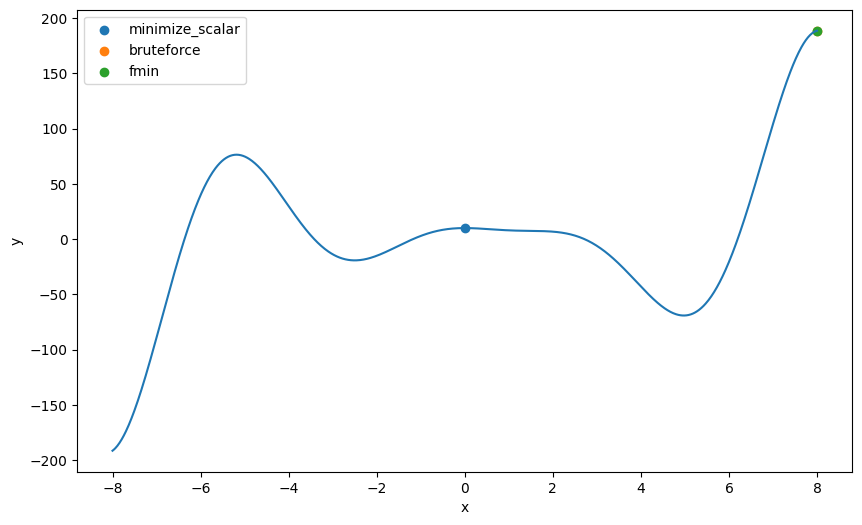

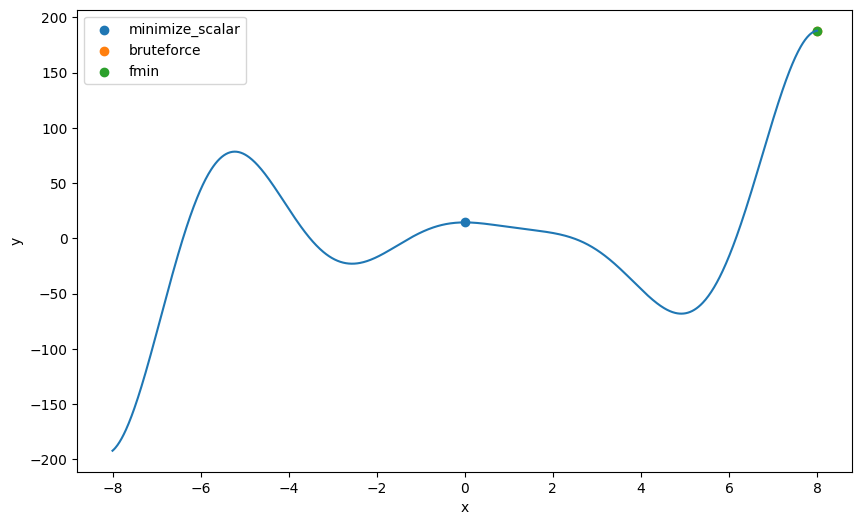

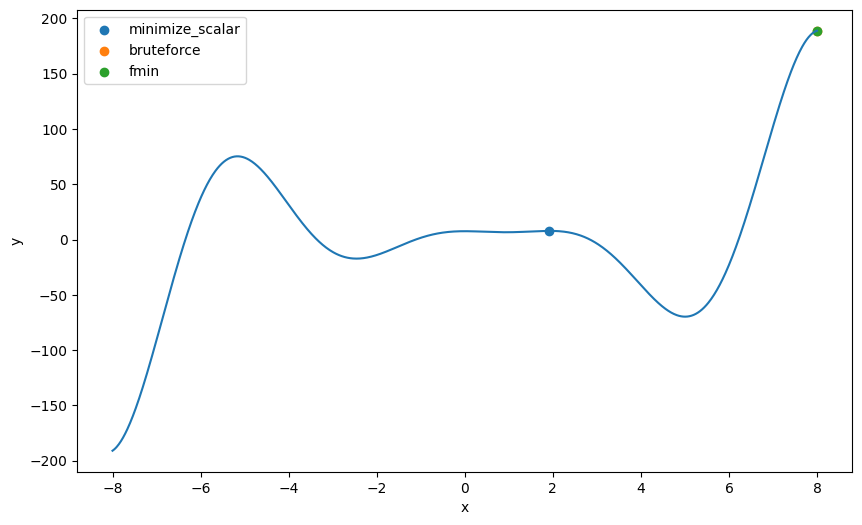

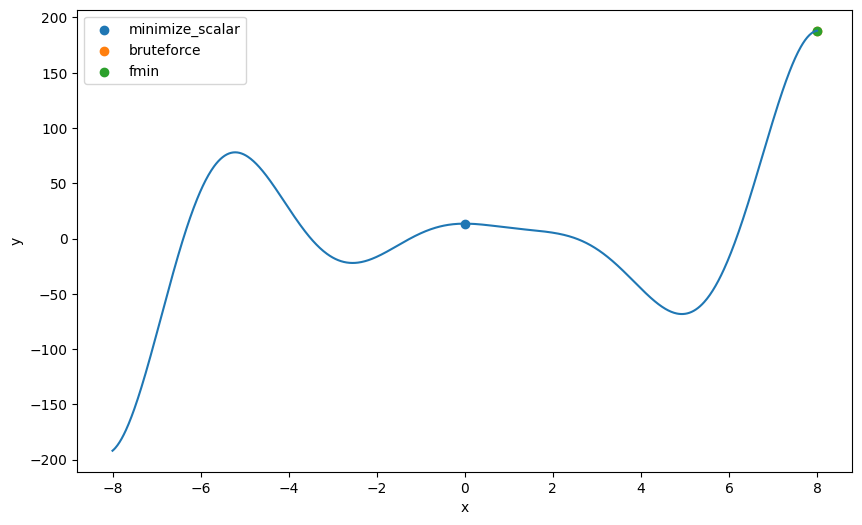

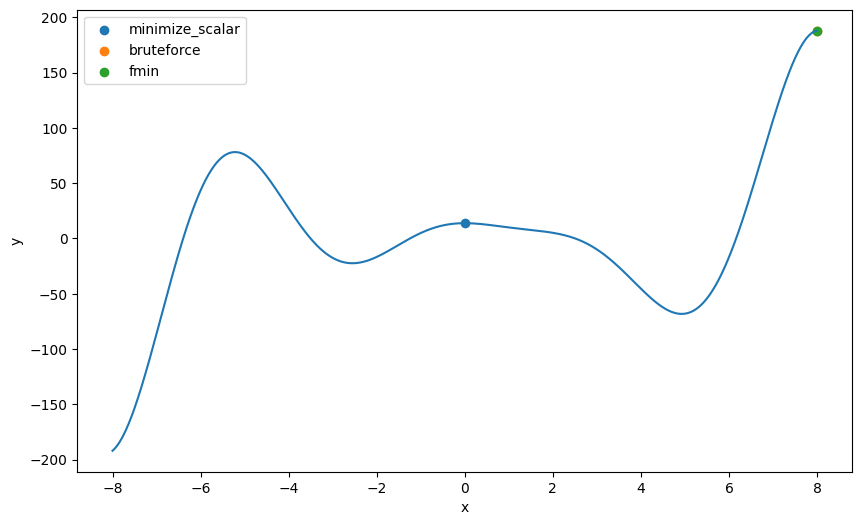

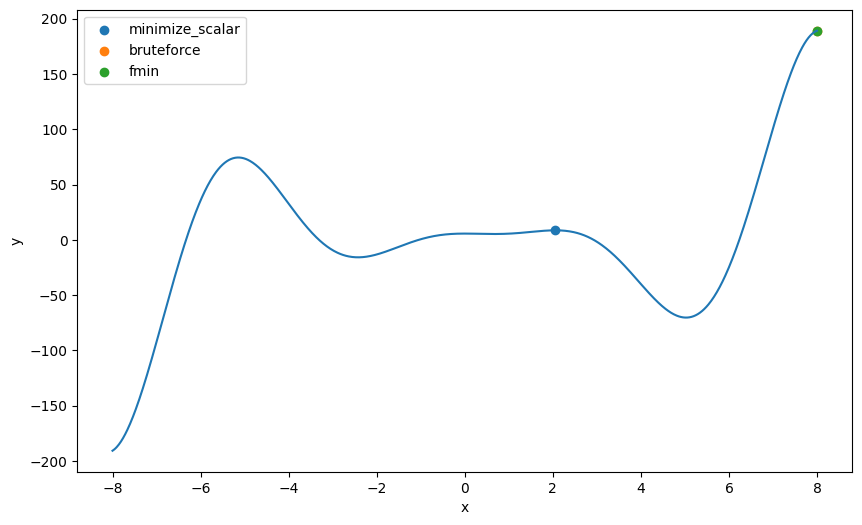

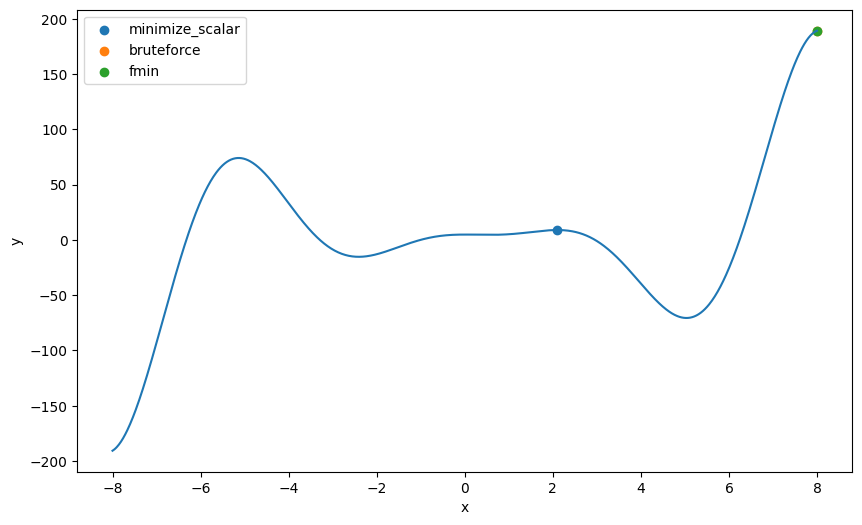

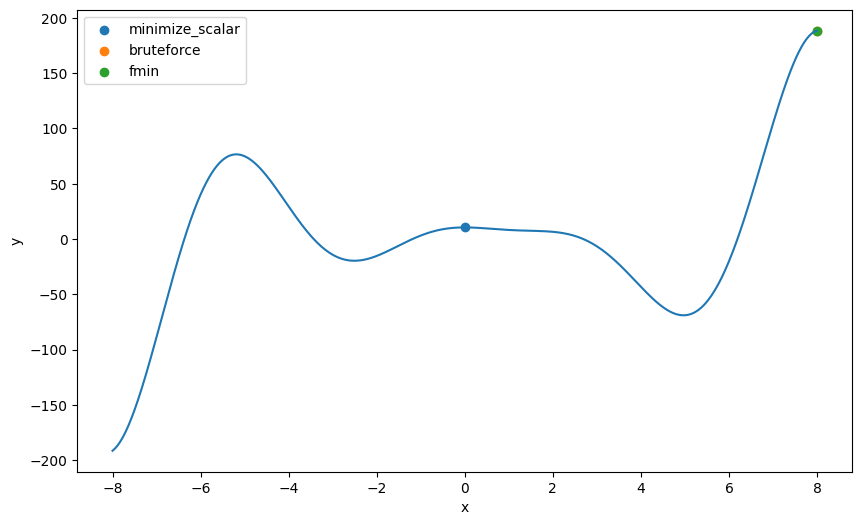

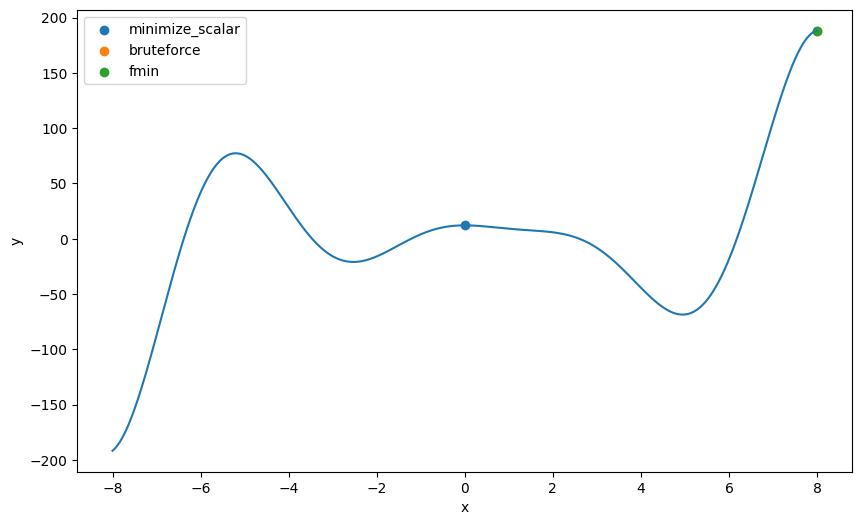

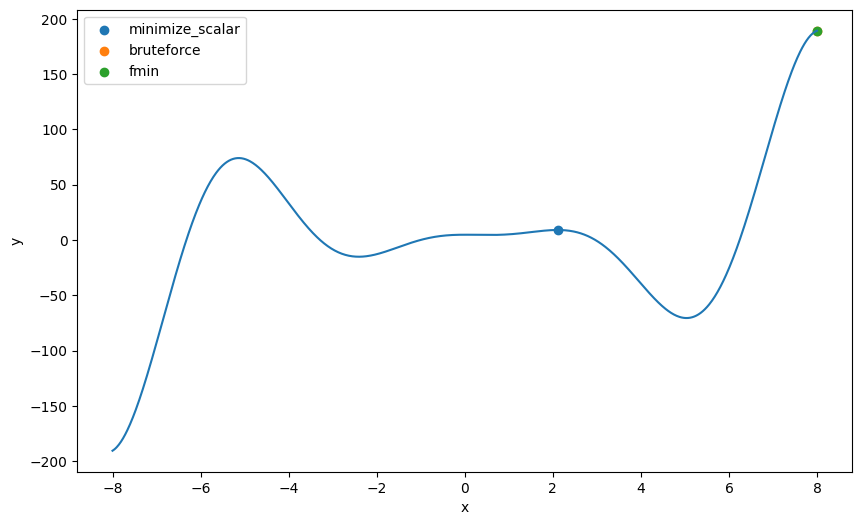

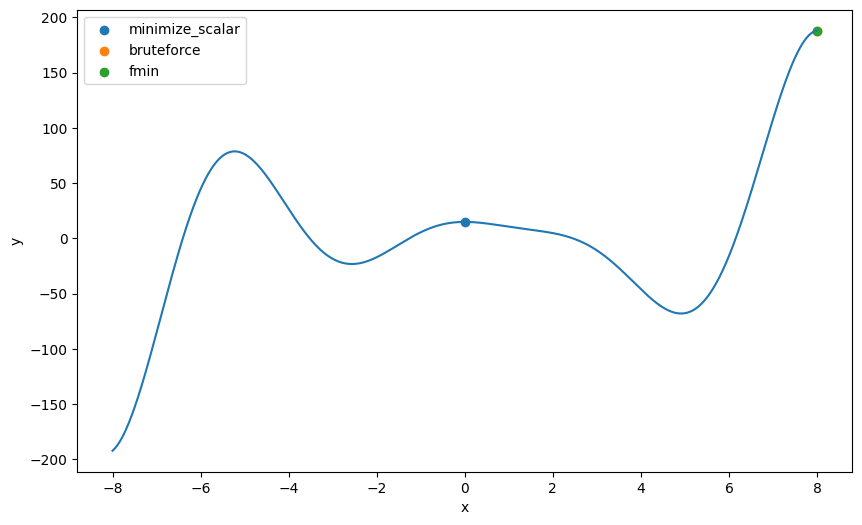

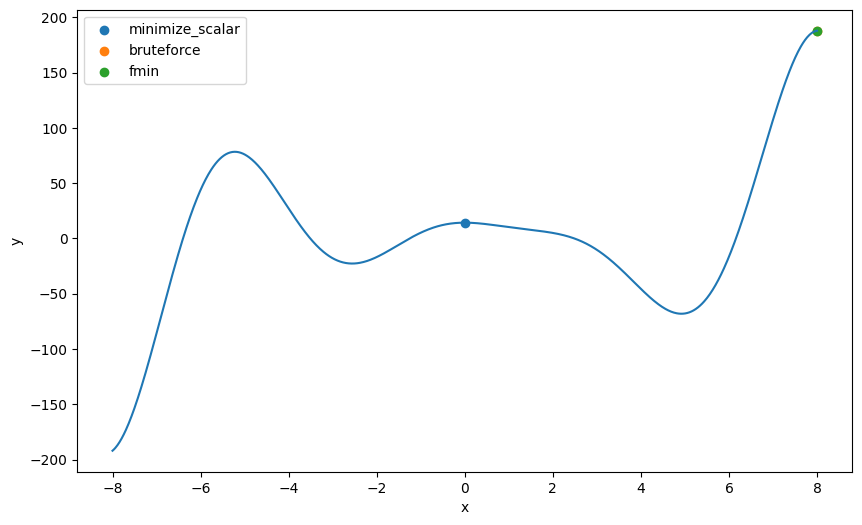

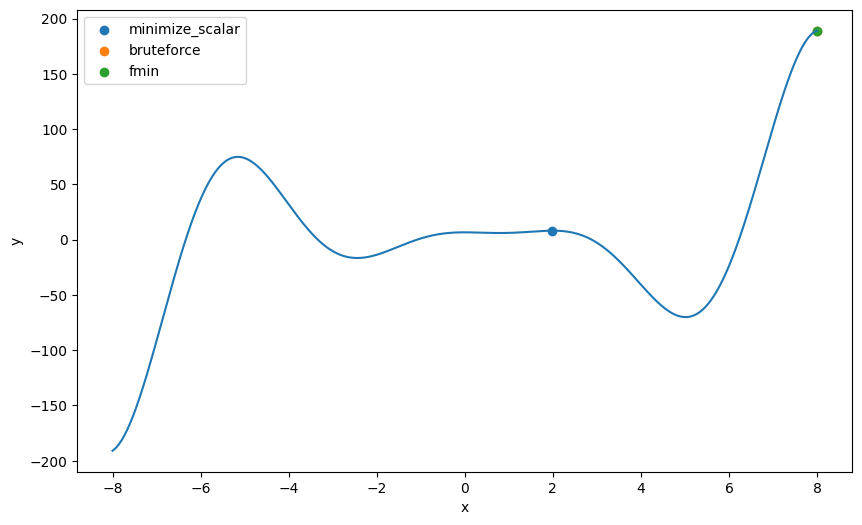

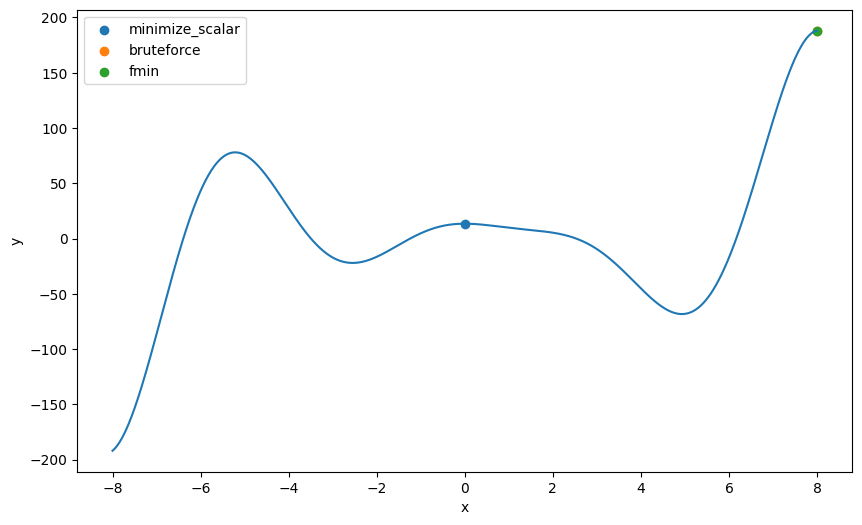

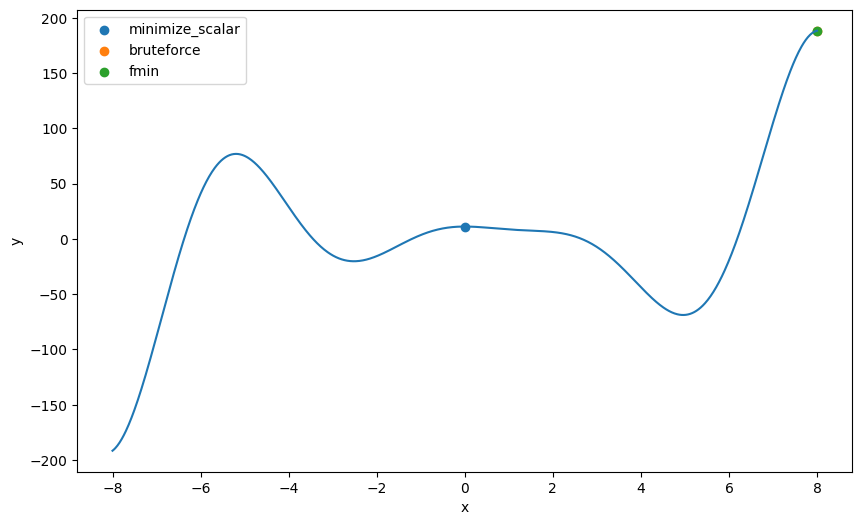

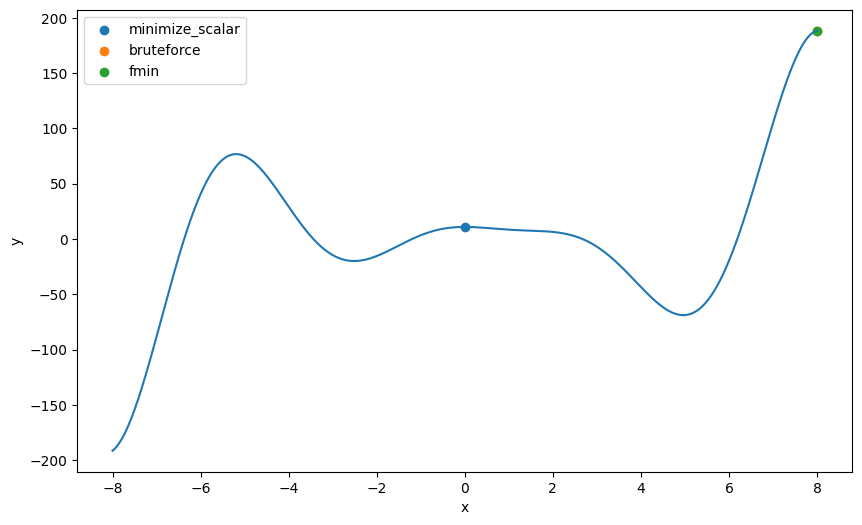

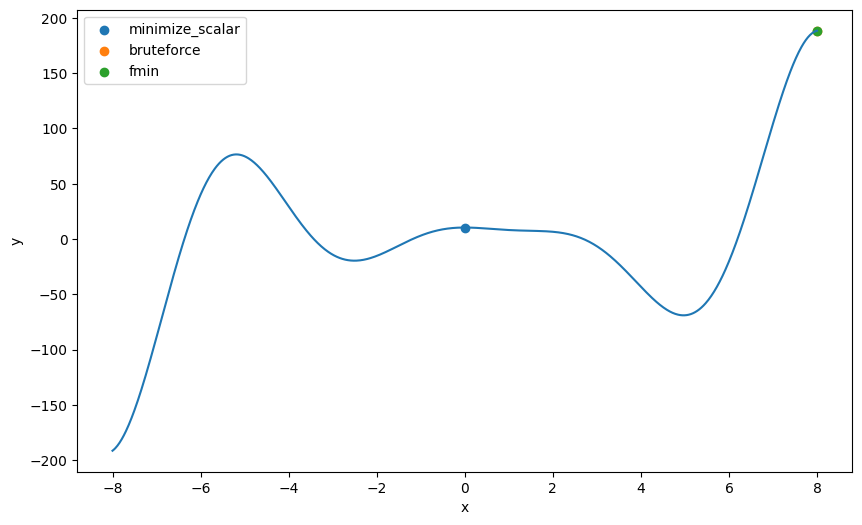

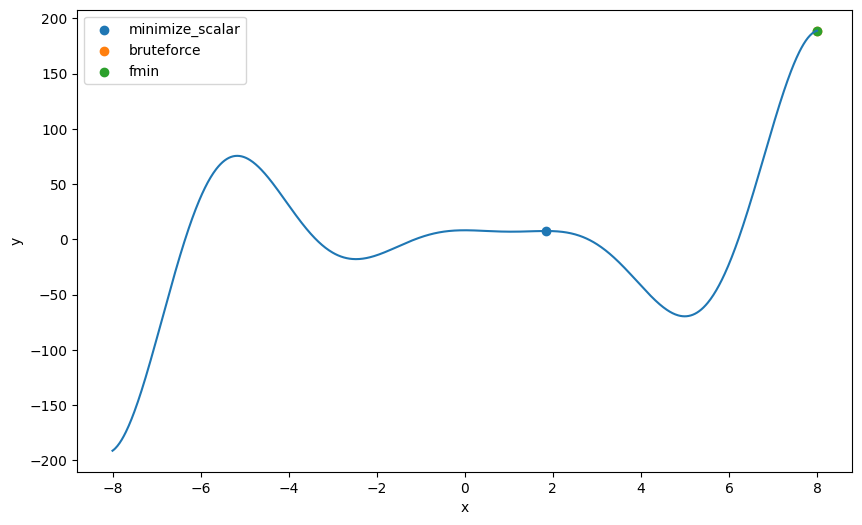

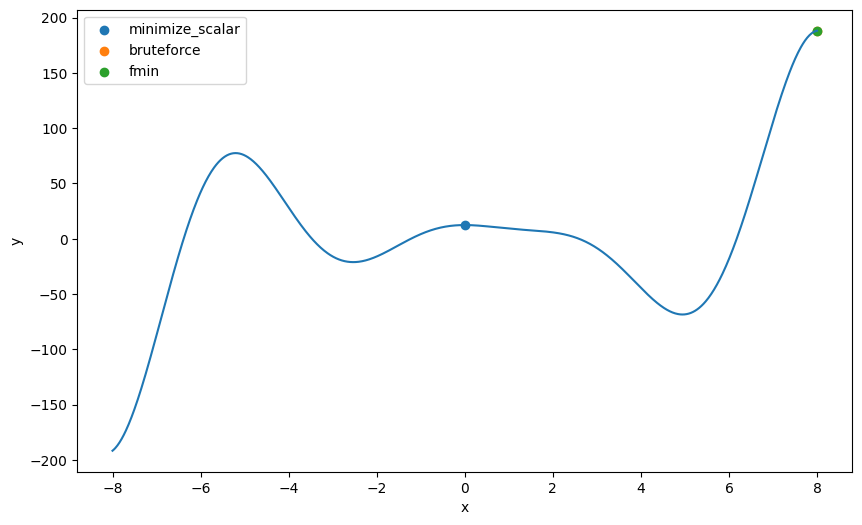

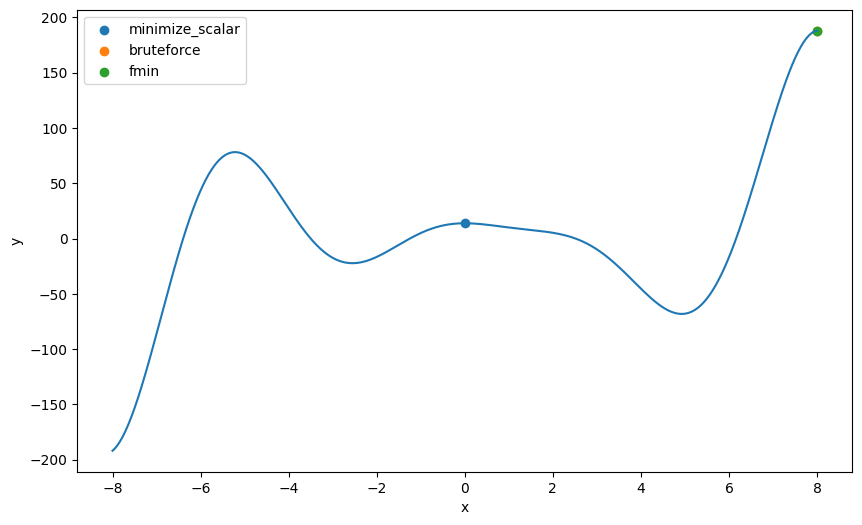

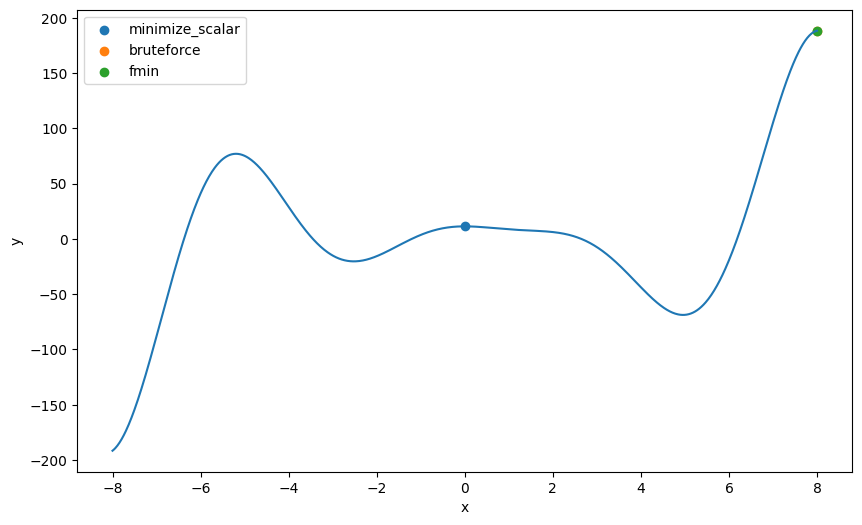

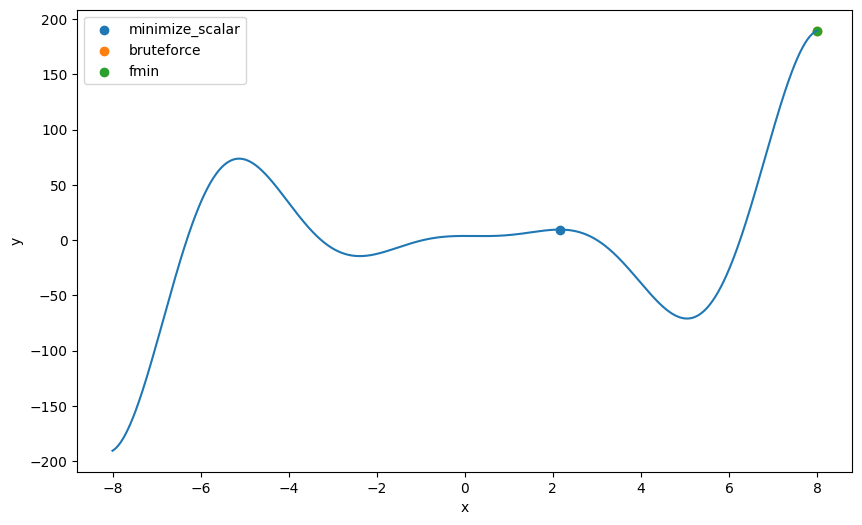

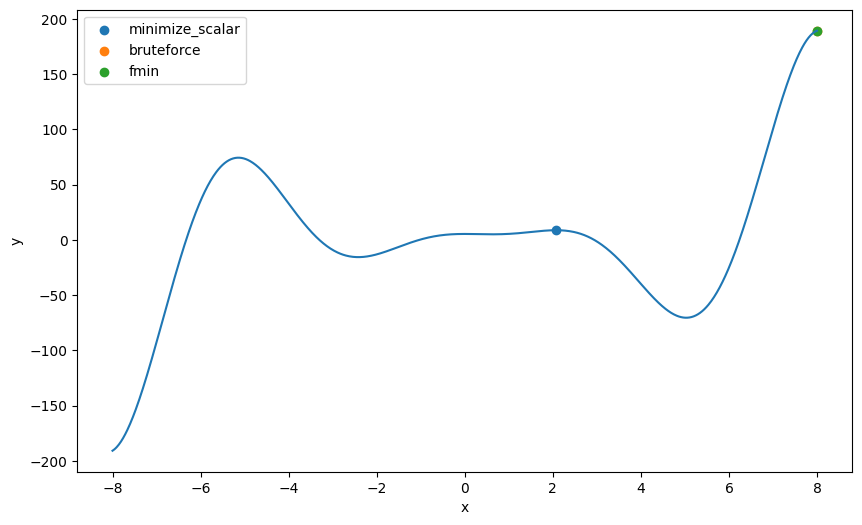

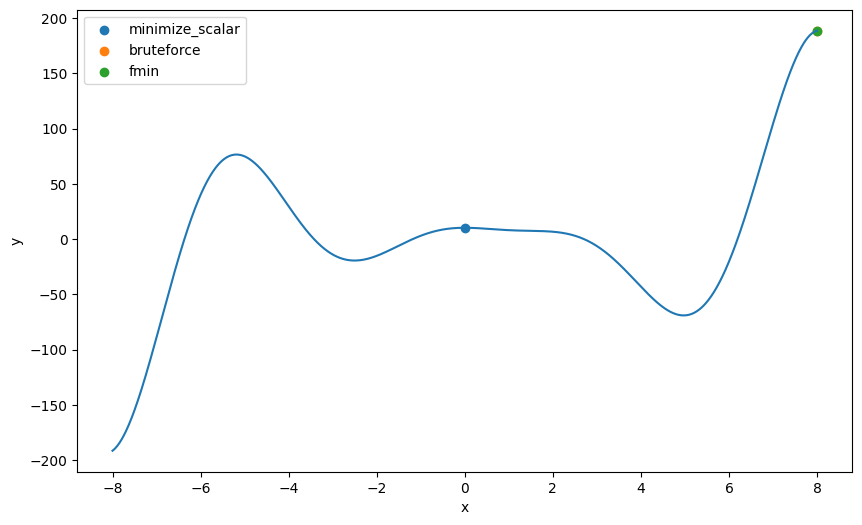

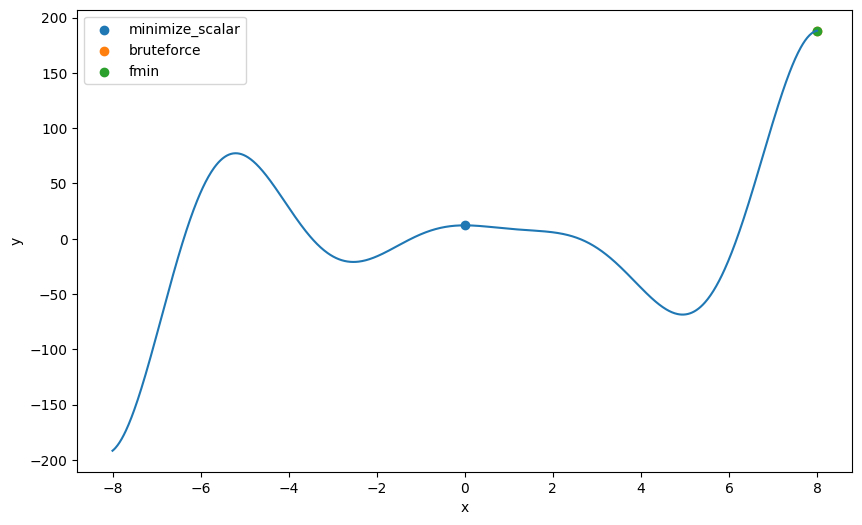

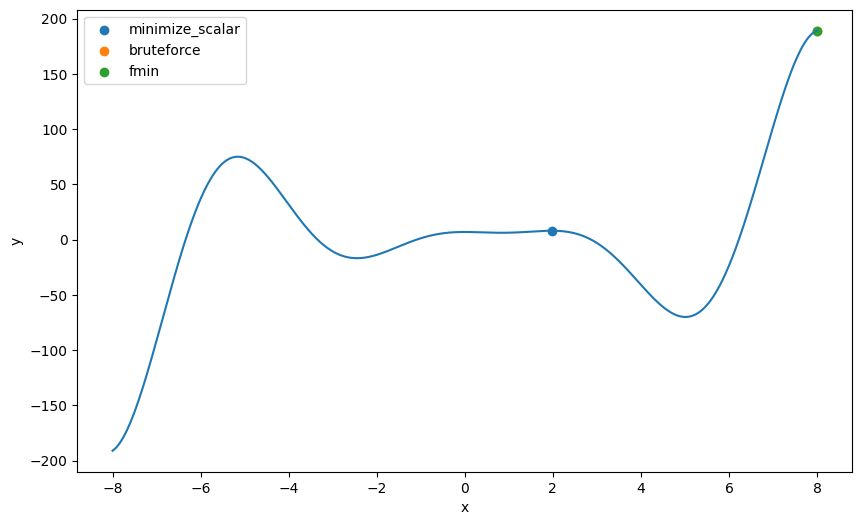

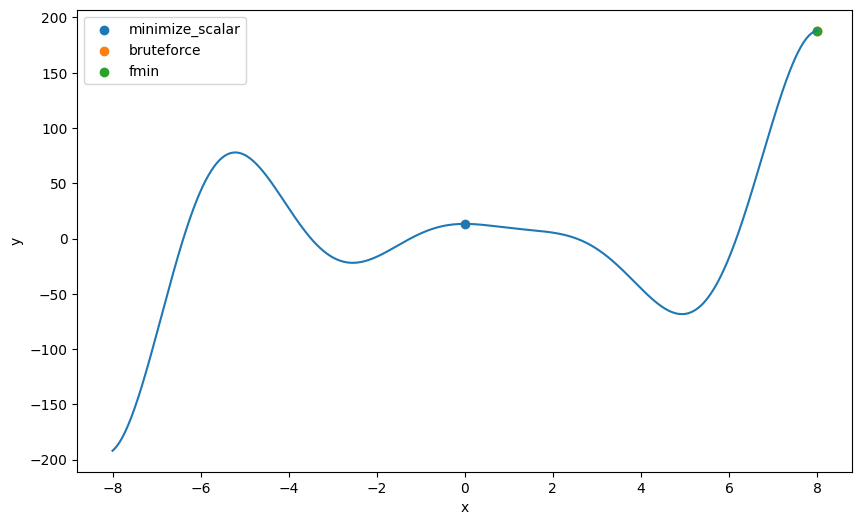

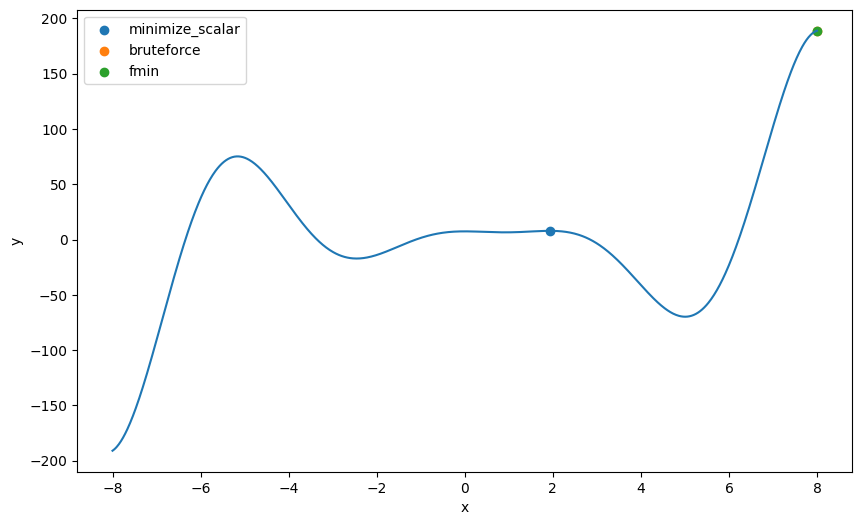

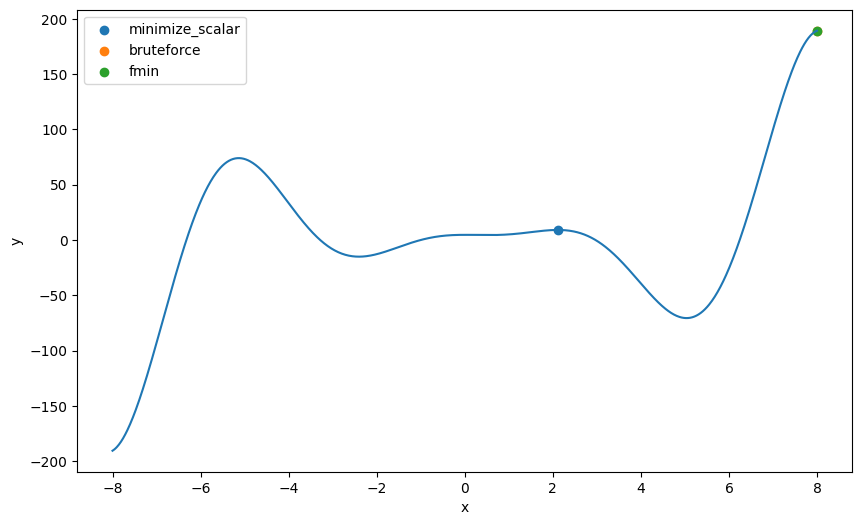

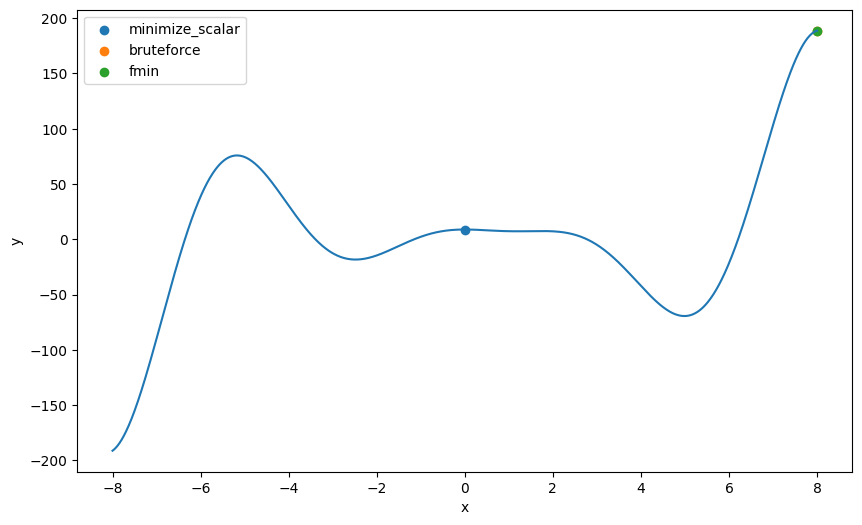

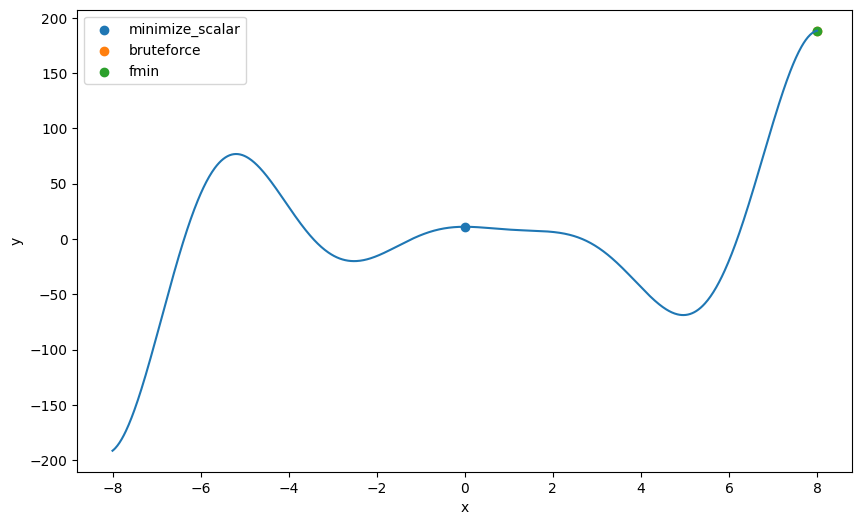

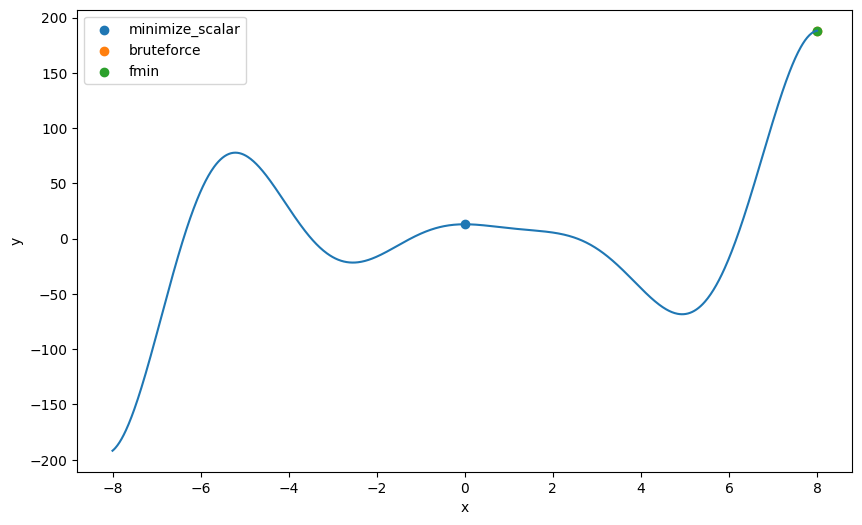

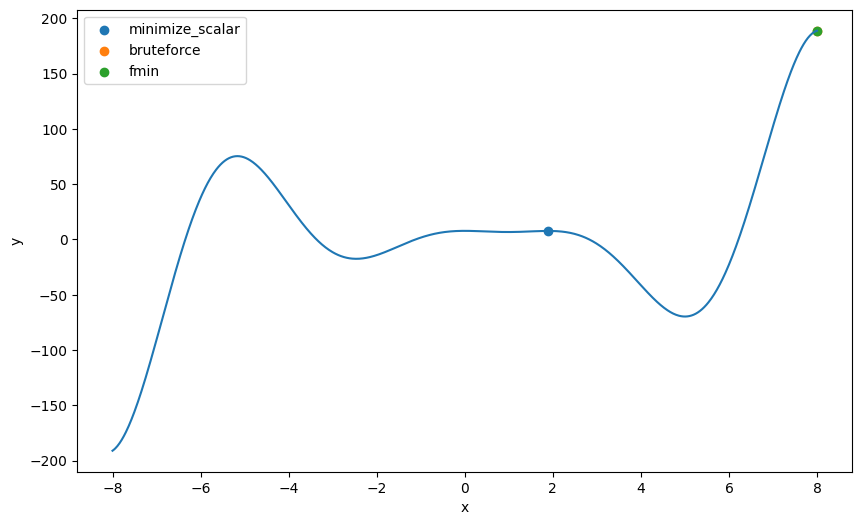

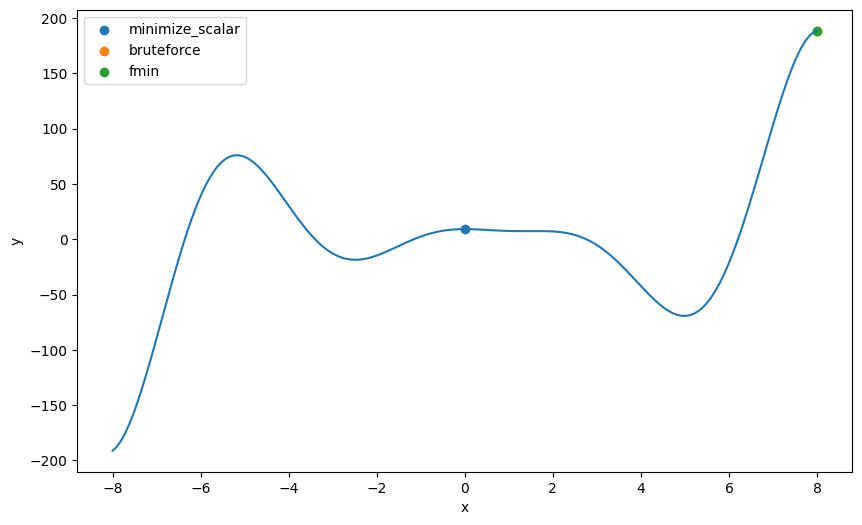

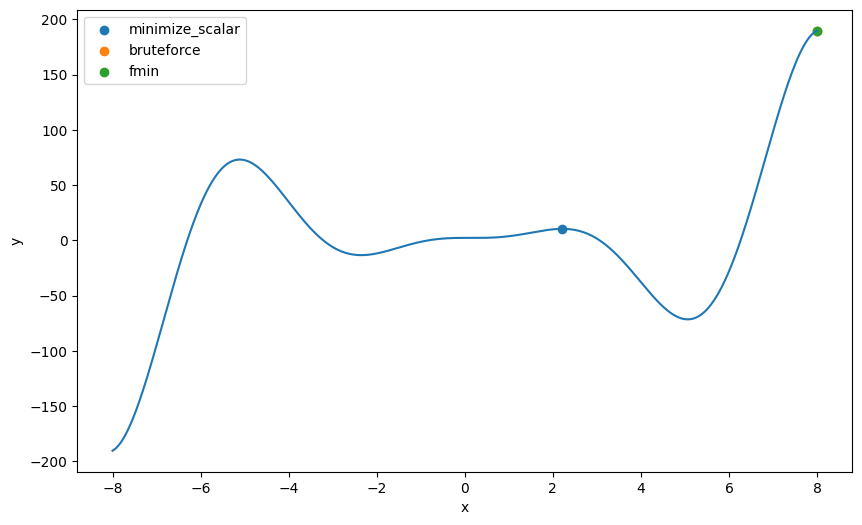

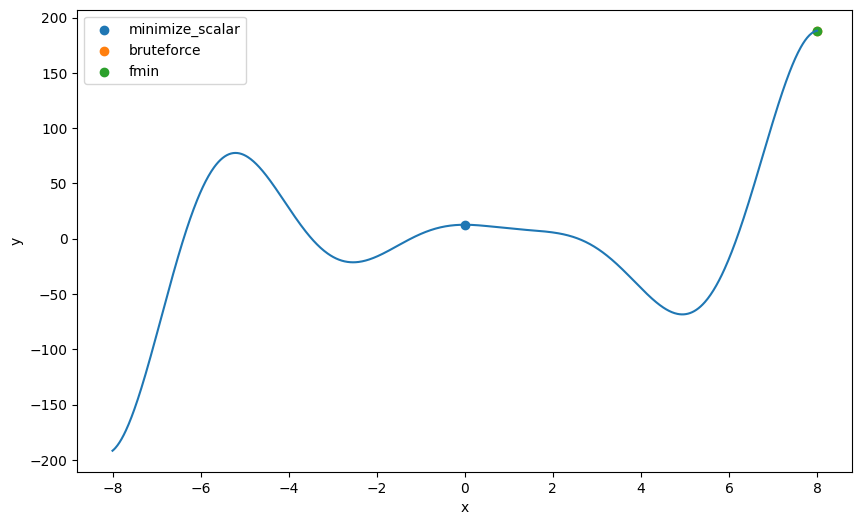

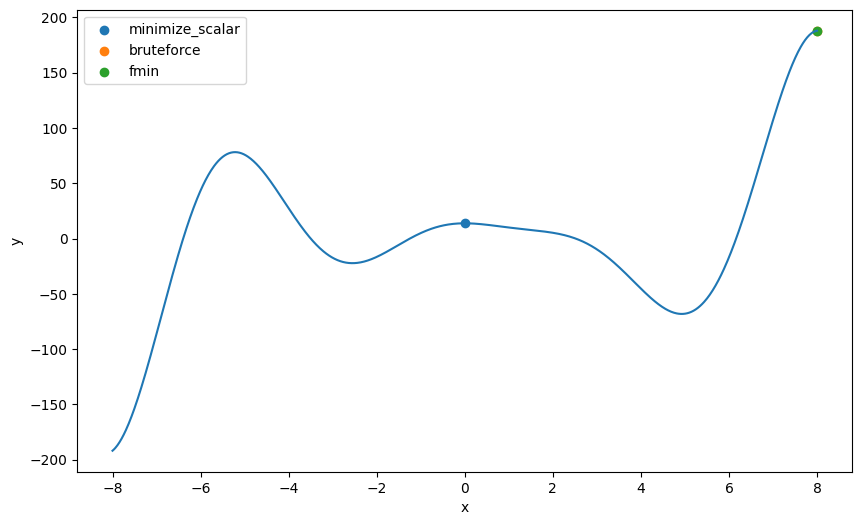

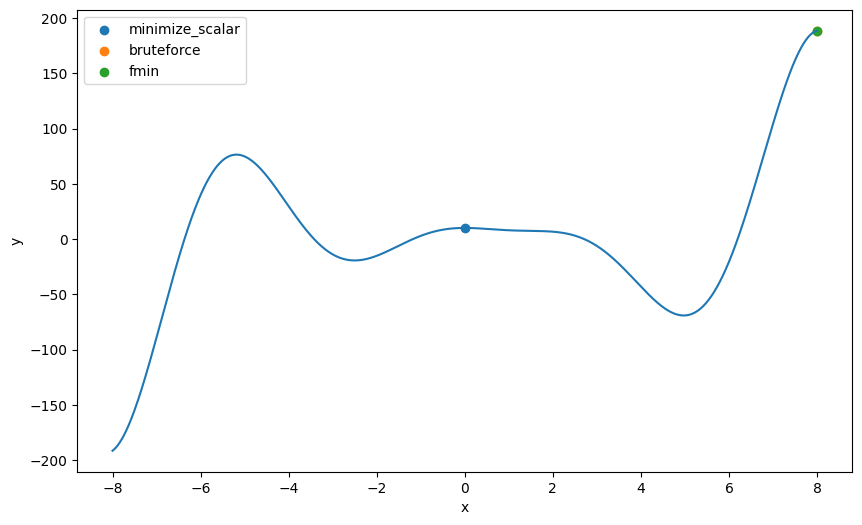

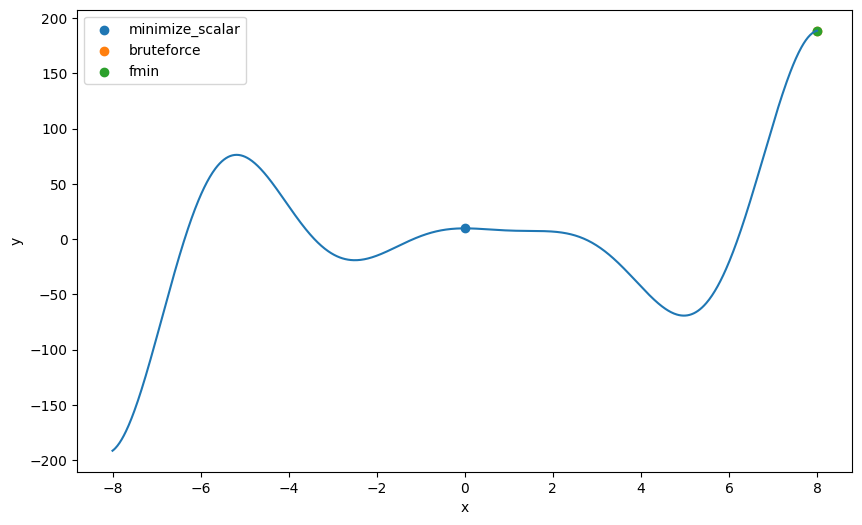

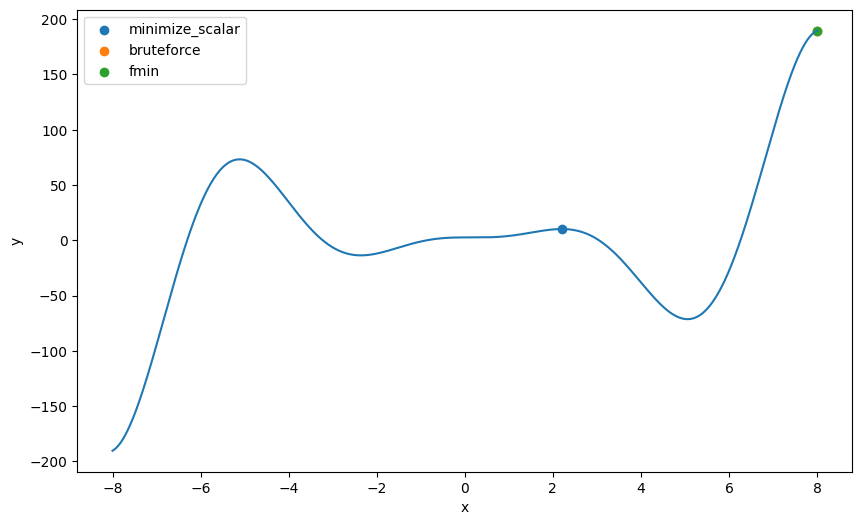

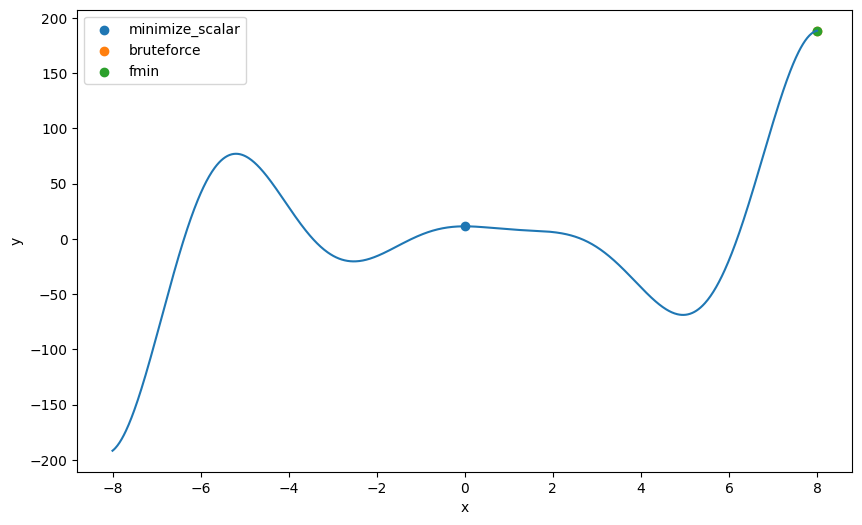

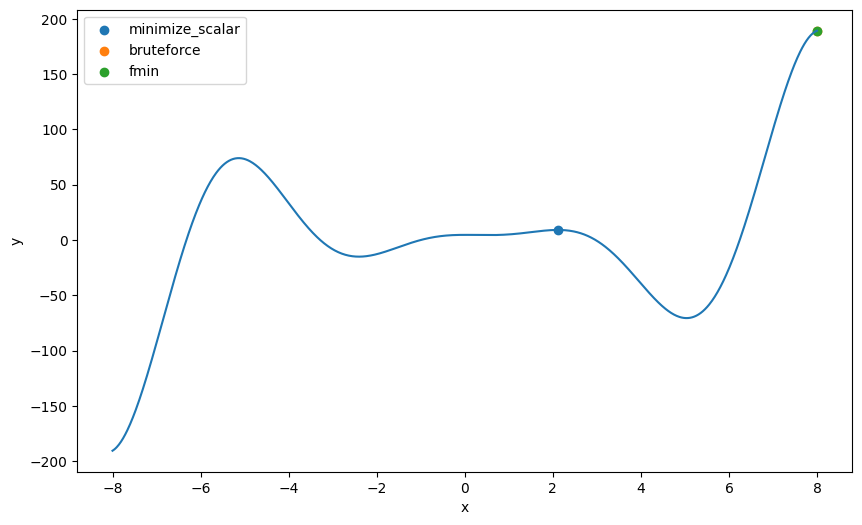

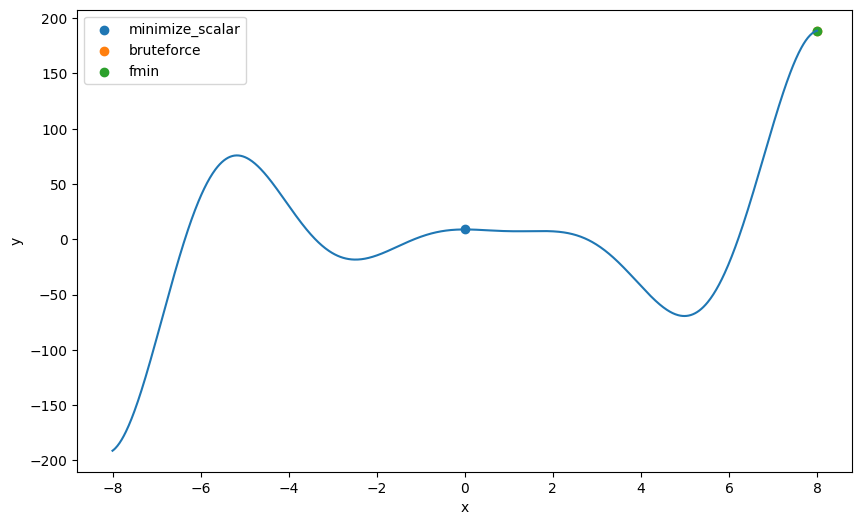

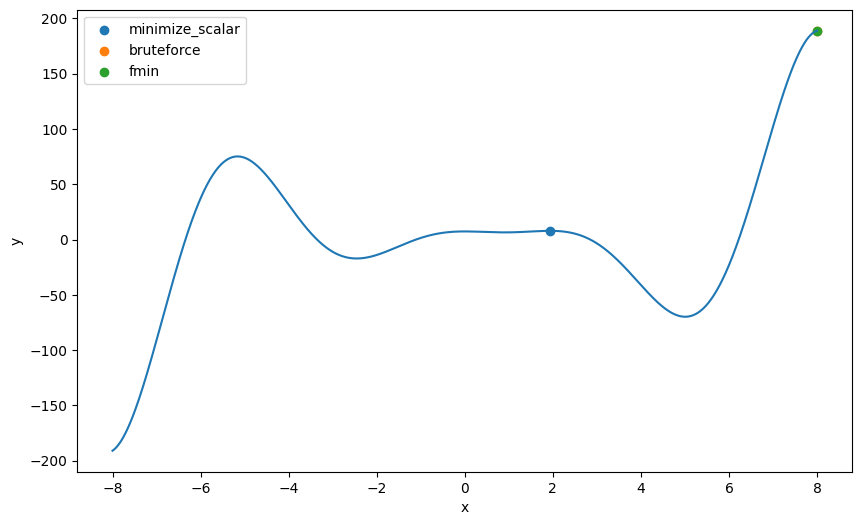

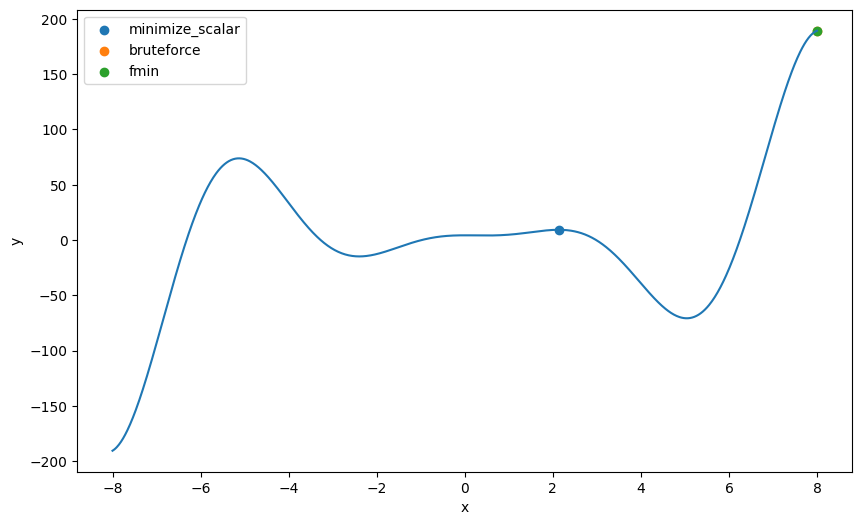

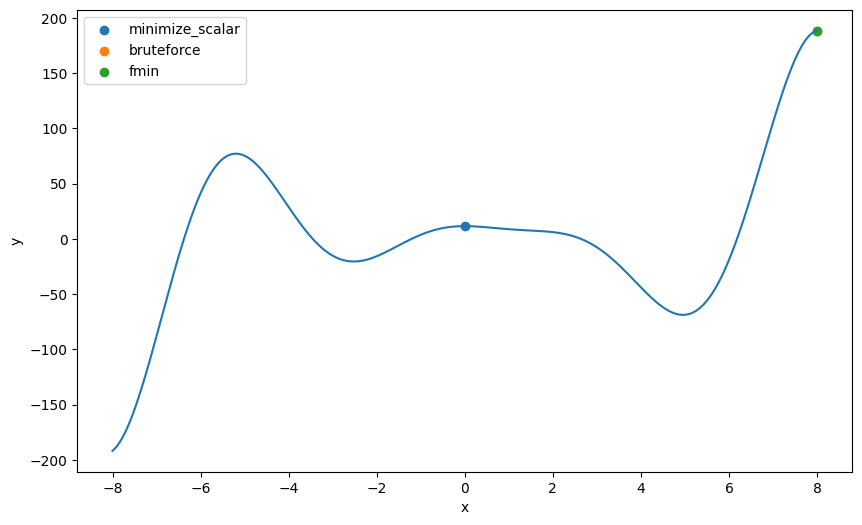

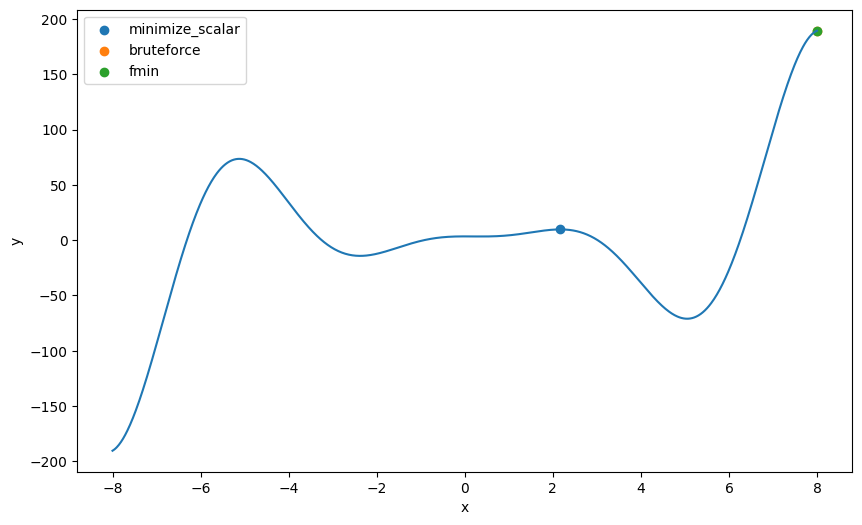

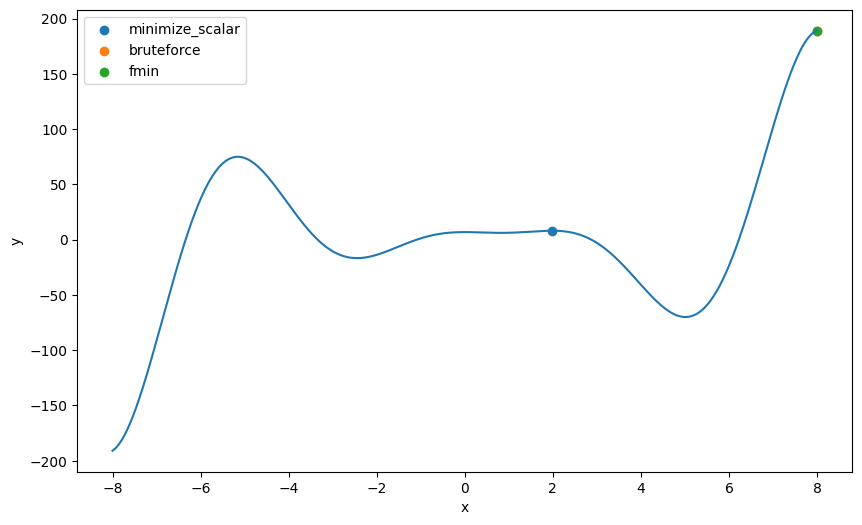

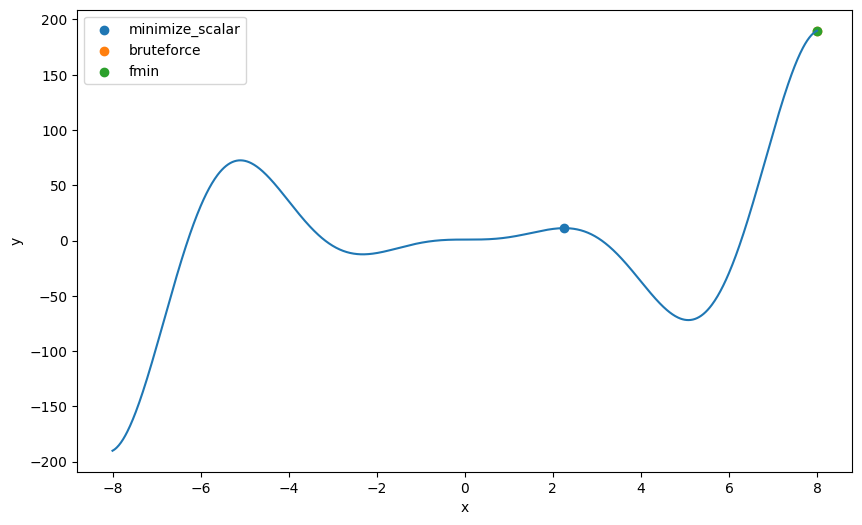

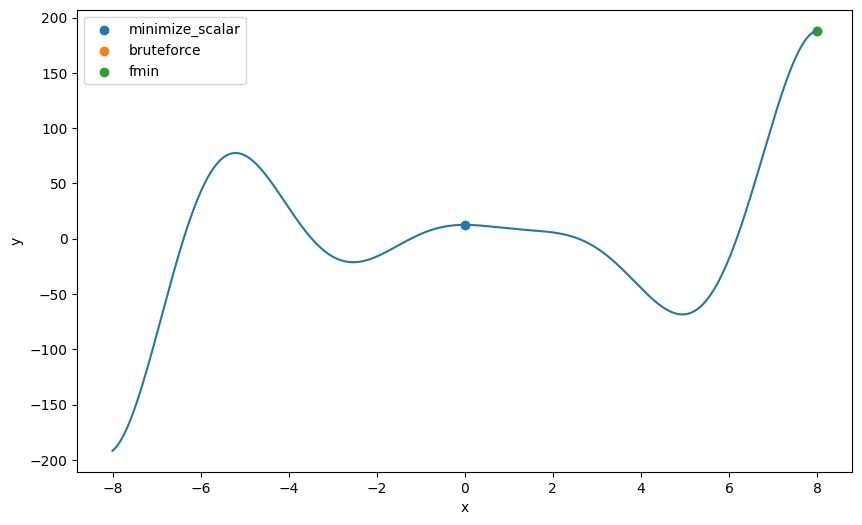

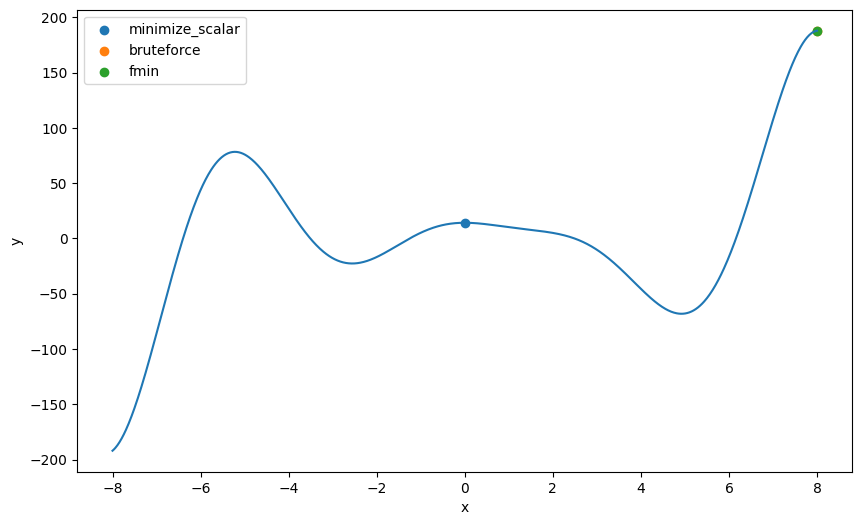

In [34]:
import random
def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def fm(x,w=8):
    return -f(x,w)

w=8
w_optimize_scalar=[]
w_fmin = []
tol=10**-5
for i in range (100):
    wrand=w*random.uniform(0.1, 2)
    res_lib=minimize_scalar(lambda x: fm(x,wrand), bounds=[x_min, x_max], method='bounded')
    x1=res_lib.x
    res_fmin=fmin(lambda x: fm(x,wrand), 7)
    if res_fmin>x_max:
        res_fmin=x_max
    elif res_fmin<x_min:
        res_fmin=x_min
    x2=bruteforce(w)
    razn=abs(x1-x2)
    razn_fmin=abs(res_fmin-x2)
    plt.figure(figsize=(10,6))
    x_arr=np.linspace(x_min,x_max,1000)
    #plt.plot(x_arr, [f(x,wrand) for x in x_arr])
    #plt.scatter(x1,f(x1,wrand), label='minimize_scalar')
    #plt.scatter(x2,f(x2,wrand), label='bruteforce')
    #plt.scatter(res_fmin,f(res_fmin,wrand), label='fmin')    
    #plt.xlabel('x')
    #plt.ylabel('y')
    #plt.legend()
    if razn>tol:
        w_optimize_scalar.append(wrand)
    if razn_fmin>tol:
        print(res_fmin, x2)
        w_fmin.append(wrand)
        
print("w для которых оптимальная точка не оптимальная при minimize_scalar:", w_optimize_scalar)
print("w для которых оптимальная точка не оптимальная при fmin:", w_fmin)

In [39]:
print(w_vse,bruteforce())

len(w_vse)

[9.695129045934742, 14.578427411012296, 9.163928976229505, 14.286505989229035, 3.156124074507243, 6.00731321236746, 14.557475431802738, 11.328392311158163, 10.845215054131646, 1.8416563466432208, 12.662800271212644, 12.929940512829026, 3.947121185236022, 1.967380226884581, 7.58749270170098, 7.43200939955258, 4.9096874493905, 5.90579876799939, 14.632218038429887, 6.159894457649191, 12.523181255168629, 12.481789208576862, 4.199446076023756, 13.137166289813745, 4.935464968372414, 0.9562399994355064, 8.069872086030095, 6.014444351941427, 5.628701706809588, 5.163122233415914, 1.420644824716483, 12.093919798462515, 2.967451670522843, 8.808831798606253, 11.368854297606685, 3.471680301181805, 10.900720433678831, 15.274269647836721, 13.785826072971474, 7.546720460628715, 7.117203805004037, 10.375896587189215, 13.073757623596695, 4.0159588502730585, 11.822140100506017, 2.3322754886411072, 1.5403722942802849, 11.494146320194663, 2.4020126873846426, 9.35249038803577, 0.9917314926809713, 3.43472112

100